<a href="https://colab.research.google.com/github/Maria-lin/F1-Analytics/blob/main/detection_anomalies_gab_v6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏧 Détection d'Anomalies sur le Réseau GAB
## Identification automatique des comportements atypiques — Support métier

---

> **Destinataires :** Experts métier – Responsables réseau GAB
> **Objectif :** Identifier automatiquement les GAB au comportement inhabituel, sans étiquette préalable
> **Approche :** Isolation Forest + Clustering KMeans — Analyse multivariée

---

### 🗺️ Ce que ce notebook raconte

```
Étape 1 — Qui sont nos GAB ?          → Comprendre le réseau avant de chercher l'anomalie
Étape 2 — Qu'est-ce qui est normal ?  → Établir la référence : volume, capture, réseau, horaires
Étape 3 — Où sont les anomalies ?     → Carte globale + score de risque
Étape 4 — Pourquoi sont-ils suspects? → Raison métier explicite par GAB
Étape 5 — Que fait-on concrètement ?  → Liste priorisée, vision annuelle, export
```

---


## 1. 🏦 Introduction Métier

### Pourquoi surveiller le comportement des GAB ?

Un **Guichet Automatique Bancaire (GAB)** enregistre chaque mois des centaines d'opérations.
Cet ensemble forme une **empreinte comportementale** stable et prévisible — jusqu'à ce qu'elle dévie.

| Signal observé | Ce que ça peut signifier |
|---|---|
| 🃏 Taux de capture de carte anormalement élevé | Fraude · Panne technique · Rétention abusive |
| 🌙 Pic d'activité nocturne inhabituel | Comportement suspect · Skimming |
| 💸 Montant moyen hors norme vs GAB comparables | Opérations inhabituelles · Retraits massifs |
| 🌍 Concentration sur réseaux étrangers (JCB, CUP…) | Tourisme concentré · Signal de fraude coordonnée |
| 📉 Volume anormalement bas | Panne non déclarée · GAB hors service |
| 🔀 Un seul réseau domine tous les retraits | Anomalie de flux · Configuration atypique |

### La valeur du modèle IA

> *"Les anomalies évidentes, on les voit déjà. Le modèle détecte ce que l'œil ne peut pas voir sur 500 automates en même temps."*

- **Combinaisons subtiles détectées** : un signal faible seul n'est pas visible — leur combinaison l'est
- **Comparaison au cluster** : chaque GAB est jugé par rapport à ses pairs, pas au réseau entier
- **Surveillance continue** : même règle, chaque mois, sur l'ensemble du parc
- **Explications lisibles** : chaque GAB atypique reçoit une raison métier en clair

---


## 2. ⚙️ Imports et Configuration

In [1]:
# ── Librairies standards ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium
from folium.plugins import MarkerCluster, HeatMap

# ── Machine Learning ───────────────────────────────────────────────────────────
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import LocalOutlierFactor

# ── Style global ───────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COULEUR_NORMAL   = '#2196F3'   # bleu
COULEUR_ANOMALIE = '#F44336'   # rouge
COULEUR_ACCENT   = '#FF9800'   # orange
COULEUR_VERT     = '#4CAF50'   # vert

# Palette clusters (8 couleurs distinctes)
PALETTE_CLUSTERS = ['#1976D2','#388E3C','#F57C00','#7B1FA2',
                    '#0097A7','#C62828','#558B2F','#4E342E']

print('✅ Librairies chargées avec succès.')


✅ Librairies chargées avec succès.


## 3. 📂 Chargement des Données

Le dataset **`fiche_identite_gab`** contient une ligne par GAB et par mois.  
Chaque ligne résume l'activité complète de l'automate sur la période.

In [2]:
# ── Chargement du dataset ─────────────────────────────────────────────────────
# En production Dataiku :
# import dataiku
# df = dataiku.Dataset('fiche_identite_gab_mensuelle').get_dataframe()

import numpy as np, pandas as pd

np.random.seed(42)
N_GAB, N_MOIS = 140, 12

# Codes postaux RÉELS — sans type_zone (absent de la fiche SQL v3)
# La catégorisation géo se fait uniquement par code postal
CONTEXTES_GEO = {
    '75001': {'lat': 48.860, 'lon':  2.347, 'base': 950, 'sig': 120},  # Paris
    '69001': {'lat': 45.764, 'lon':  4.835, 'base': 720, 'sig': 100},  # Lyon
    '13001': {'lat': 43.297, 'lon':  5.381, 'base': 770, 'sig': 110},  # Marseille
    '33000': {'lat': 44.837, 'lon': -0.579, 'base': 660, 'sig':  90},  # Bordeaux
    '59000': {'lat': 50.629, 'lon':  3.057, 'base': 610, 'sig':  85},  # Lille
    '06000': {'lat': 43.710, 'lon':  7.262, 'base': 830, 'sig': 105},  # Nice (touristique)
    '97150': {'lat': 18.073, 'lon':-63.082, 'base': 185, 'sig':  42},  # Saint-Martin
    '97100': {'lat': 16.008, 'lon':-61.706, 'base': 230, 'sig':  52},  # Guadeloupe
    '97300': {'lat':  4.922, 'lon':-52.313, 'base': 205, 'sig':  46},  # Guyane (rural)
    '97400': {'lat':-21.115, 'lon': 55.536, 'base': 195, 'sig':  44},  # Réunion
}
CPS  = list(CONTEXTES_GEO.keys())
PROB = [0.18, 0.12, 0.11, 0.10, 0.11, 0.08, 0.05, 0.05, 0.10, 0.10]

# Saisonnalité mensuelle réaliste
SAISON     = {1:.90,2:.88,3:.93,4:.96,5:.98,6:1.05,7:1.13,8:1.16,9:1.01,10:.97,11:.95,12:1.19}
SAISON_ETR = {1:.4,2:.4,3:.5,4:.7,5:.9,6:1.4,7:2.4,8:2.6,9:1.2,10:.6,11:.4,12:.5}
SAISON_CUP = {1:2.0,2:2.2,3:1.0,4:.8,5:.8,6:1.2,7:2.0,8:2.2,9:1.0,10:.7,11:.6,12:.9}

# 4 profils d'anomalies distincts pour varier les raisons
PROFILS_ANOM = ['CAPTURE_ELEVEE','NOCTURNE','RESEAU_ETRANGER','MONTANT_ELEVE']

rows = []
for gab_id in range(N_GAB):
    cp   = np.random.choice(CPS, p=PROB)
    ctx  = CONTEXTES_GEO[cp]
    is_dom = cp.startswith('97')
    is_anom = (gab_id >= N_GAB - 18)
    profil_anom = PROFILS_ANOM[gab_id % len(PROFILS_ANOM)] if is_anom else None

    for m in range(1, N_MOIS+1):
        s = SAISON[m]; se = SAISON_ETR[m]; sc = SAISON_CUP[m]
        base = ctx['base']; sig = ctx['sig']

        if is_anom:
            if profil_anom == 'CAPTURE_ELEVEE':
                rh=int(np.clip(np.random.normal(base*1.1*s,sig),30,None))
                tc=float(np.clip(np.random.normal(9.5,2.0),0,None))
                pn=float(np.clip(np.random.normal(12,4),0,100))
                pw=float(np.clip(np.random.normal(24,5),0,100))
                jcb=int(np.clip(np.random.normal(5*se,3),0,None))
                amx=int(np.clip(np.random.normal(4*se,2),0,None))
                cup=int(np.clip(np.random.normal(6*sc,4),0,None))
                montant_moy=float(np.clip(np.random.normal(160,25),30,None))
            elif profil_anom == 'NOCTURNE':
                rh=int(np.clip(np.random.normal(base*1.2*s,sig*1.3),30,None))
                tc=float(np.clip(np.random.normal(0.9,0.4),0,None))
                pn=float(np.clip(np.random.normal(42,8),0,100))
                pw=float(np.clip(np.random.normal(28,6),0,100))
                jcb=int(np.clip(np.random.normal(5*se,3),0,None))
                amx=int(np.clip(np.random.normal(4*se,2),0,None))
                cup=int(np.clip(np.random.normal(5*sc,3),0,None))
                montant_moy=float(np.clip(np.random.normal(165,28),30,None))
            elif profil_anom == 'RESEAU_ETRANGER':
                rh=int(np.clip(np.random.normal(base*1.3*s,sig),30,None))
                tc=float(np.clip(np.random.normal(0.8,0.3),0,None))
                pn=float(np.clip(np.random.normal(11,3),0,100))
                pw=float(np.clip(np.random.normal(23,5),0,100))
                jcb=int(np.clip(np.random.normal(180*se,50),0,None))
                amx=int(np.clip(np.random.normal(90*se,25),0,None))
                cup=int(np.clip(np.random.normal(120*sc,35),0,None))
                montant_moy=float(np.clip(np.random.normal(172,30),30,None))
            else:  # MONTANT_ELEVE
                rh=int(np.clip(np.random.normal(base*0.9*s,sig),30,None))
                tc=float(np.clip(np.random.normal(0.7,0.3),0,None))
                pn=float(np.clip(np.random.normal(11,3),0,100))
                pw=float(np.clip(np.random.normal(23,4),0,100))
                jcb=int(np.clip(np.random.normal(5*se,3),0,None))
                amx=int(np.clip(np.random.normal(4*se,2),0,None))
                cup=int(np.clip(np.random.normal(5*sc,3),0,None))
                montant_moy=float(np.clip(np.random.normal(480,80),100,None))
            flag_sql=1
        else:
            rh=int(np.clip(np.random.normal(base*s,sig),10,None))
            tc=float(np.clip(np.random.normal(0.5,0.3),0,None))
            pn=float(np.clip(np.random.normal(10,3),0,100))
            pw=float(np.clip(np.random.normal(22,4),0,100))
            jcb=int(np.clip(np.random.normal(4*se,3),0,None))
            amx=int(np.clip(np.random.normal(3*se,2),0,None))
            cup=int(np.clip(np.random.normal(5*sc,4),0,None))
            montant_moy=float(np.clip(np.random.normal(150,22),30,None))
            flag_sql=0

        rc  = int(np.clip(np.random.normal(55,18),0,None))
        cap = max(0,int(tc*rh/100))
        dfs = int(np.clip(np.random.normal(2*se,1.5),0,None))

        rows.append({
            'num_automate':f'GAB_{gab_id:04d}','annee':2024,'mois':m,
            'code_postale_emplacement':cp,
            'type_gab_e_i':np.random.choice(['Interne','Externe'],p=[.4,.6]),
            'longitude':ctx['lon']+np.random.normal(0,.03),
            'latitude': ctx['lat']+np.random.normal(0,.03),
            # Retraits
            'ret_nb':rh+rc,'ret_nb_horscos':rh,'ret_nb_cos':rc,
            'ret_nb_jours_actifs':np.random.randint(20,31),
            'ret_montant_total':rh*montant_moy if is_anom else rh*float(np.random.normal(150,20)),
            'ret_montant_moyen':montant_moy if is_anom else float(np.clip(np.random.normal(150,22),30,None)),
            'ret_montant_max':float(np.clip(np.random.normal(500 if not is_anom else 1100,65),80,None)),
            'ret_montant_min':float(np.clip(np.random.normal(20,5),5,None)),
            'ret_montant_stddev':float(np.clip(np.random.normal(58 if not is_anom else 175,12),1,None)),
            'ret_nb_nuit':int(rh*pn/100),'ret_nb_weekend':int(rh*pw/100),
            'ret_pct_nuit':pn,'ret_pct_weekend':pw,
            # Captures
            'cap_nb':cap,'taux_capture_pct':tc,
            'cap_cos_nb':int(np.clip(np.random.poisson(.8),0,None)),
            'taux_capture_cos_pct':(int(np.clip(np.random.poisson(.8),0,None))/(rc+1)*100),
            'cap_nb_oubli_ou_incident_lecture':int(cap*.30),
            'cap_nb_code_confidentiel_depasse':int(cap*.35),
            'cap_nb_carte_perdue':int(cap*.10),
            'cap_nb_carte_volee':int(cap*.08),
            'cap_nb_autre_motif':max(0,cap-int(cap*.83)),
            # Réseaux locaux
            'nb_ope_reseau_cb':int(np.clip(np.random.normal(350*s,55),0,None)),
            'nb_ope_reseau_visa':int(np.clip(np.random.normal(180*s,38),0,None)),
            'nb_ope_reseau_mastercard':int(np.clip(np.random.normal(120*s,27),0,None)),
            'nb_ope_reseau_interne':int(np.clip(np.random.normal(80,18),0,None)),
            'nb_ope_reseau_franfinance':int(np.clip(np.random.normal(30,9),0,None)),
            'nb_ope_reseau_cos':rc,
            'nb_ope_reseau_trionis':int(np.clip(np.random.normal(15,6),0,None)),
            'nb_ope_reseau_ppl':int(np.clip(np.random.normal(12,5),0,None)),
            'nb_ope_reseau_cofinoga':int(np.clip(np.random.normal(8,4),0,None)),
            'nb_ope_reseau_casino':int(np.clip(np.random.normal(10,4),0,None)),
            'nb_ope_reseau_accord':int(np.clip(np.random.normal(25,8),0,None)),
            'nb_ope_reseau_postepargne':int(np.clip(np.random.normal(5,3),0,None)),
            'nb_ope_reseau_autres':int(np.clip(np.random.normal(10,4),0,None)),
            # Réseaux étrangers
            'nb_ope_reseau_jcb':jcb,
            'nb_ope_reseau_amex':amx,
            'nb_ope_reseau_cup':cup,
            'nb_ope_reseau_carte_diners_et_discovery':dfs,
            # Montants réseaux
            'montant_reseau_jcb':jcb*float(np.random.uniform(80,250)),
            'montant_reseau_amex':amx*float(np.random.uniform(80,250)),
            'montant_reseau_cup':cup*float(np.random.uniform(90,220)),
            # Flags SQL
            'flag_atypique':flag_sql,
            'nb_metriques_anormales':int(np.random.choice([2,3,4,5])) if flag_sql else int(np.random.choice([0,0,0,1],p=[.6,.2,.15,.05])),
        })

df = pd.DataFrame(rows)
df['ret_montant_total'] = df.apply(lambda r: r['ret_nb_horscos']*r['ret_montant_moyen'], axis=1)

print(f'📊 Dataset : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'   → {df["num_automate"].nunique()} GAB  |  {df["mois"].nunique()} mois')
print(f'   → DOM-TOM : {df[df["code_postale_emplacement"].str.startswith("97")]["num_automate"].nunique()} GAB')
print(f'   → GAB atypiques (flag SQL=1) : {df[df["flag_atypique"]==1]["num_automate"].nunique()}')
print(f'   → Réseaux disponibles : JCB · CUP · Amex · Diners + 13 réseaux locaux')


📊 Dataset : 1,680 lignes × 51 colonnes
   → 140 GAB  |  12 mois
   → DOM-TOM : 44 GAB
   → GAB atypiques (flag SQL=1) : 18
   → Réseaux disponibles : JCB · CUP · Amex · Diners + 13 réseaux locaux


## 4. 🧹 Prétraitement des Données

Avant toute modélisation, nous vérifions la qualité des données et créons des variables métier enrichies.

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# 4.1  AUDIT DE QUALITÉ
# ══════════════════════════════════════════════════════════════════════════════
print('─'*65)
print('  🔍 AUDIT DE QUALITÉ DES DONNÉES')
print('─'*65)

manquants = df.isnull().sum()
if manquants.sum() > 0:
    pct = (manquants/len(df)*100).round(1)
    a = pd.DataFrame({'Nb NaN':manquants,'% NaN':pct})
    a = a[a['Nb NaN']>0].sort_values('% NaN',ascending=False)
    print(f'\n⚠️  Colonnes avec valeurs manquantes ({len(a)}) :')
    print(a.to_string())
else:
    print('\n✅ Aucune valeur manquante détectée.')

cp_col = 'code_postale_emplacement' if 'code_postale_emplacement' in df.columns else 'code_postal'

for coord in ['latitude','longitude']:
    if coord in df.columns and df[coord].isnull().any():
        df[coord] = df[coord].fillna(df.groupby(cp_col)[coord].transform('median'))
        df[coord] = df[coord].fillna(df[coord].median())

if 'taux_capture_cos_pct' in df.columns:
    df['taux_capture_cos_pct'] = df['taux_capture_cos_pct'].fillna(0)

cols_zero = [c for c in df.columns if c.startswith(('nb_ope_reseau_','montant_reseau_','cap_nb_'))]
df[cols_zero] = df[cols_zero].fillna(0)

for col in ['ret_pct_nuit','ret_pct_weekend','taux_capture_pct']:
    if col in df.columns and df[col].isnull().any():
        df[col] = df[col].fillna(df.groupby('type_gab_e_i')[col].transform('median'))
        df[col] = df[col].fillna(df[col].median())

df['type_gab_e_i'] = df['type_gab_e_i'].fillna('Inconnu')

for col in ['taux_capture_pct','ret_pct_nuit','ret_pct_weekend']:
    if col in df.columns: df[col] = df[col].clip(0,100)
df['ret_nb']        = df['ret_nb'].clip(0)
df['ret_nb_horscos'] = df['ret_nb_horscos'].clip(0)
print('\n🔧 Données nettoyées et incohérences corrigées.')

# ══════════════════════════════════════════════════════════════════════════════
# 4.2  CONTEXTE GÉOGRAPHIQUE — basé sur le code postal uniquement
# ══════════════════════════════════════════════════════════════════════════════
# ⚠️ La colonne type_zone n'existe PAS dans la fiche SQL v3.
# On catégorise depuis le code postal pour éviter des biais
# (ex : Guyane classée "urbaine" si on ne fait pas ce travail).

df['is_dom_tom'] = df[cp_col].astype(str).str.startswith('97').astype(int)

def categoriser_geo(cp):
    cp = str(cp)
    if cp == '97150': return 'Saint-Martin'
    if cp.startswith('971'): return 'Guadeloupe'
    if cp.startswith('972'): return 'Martinique'
    if cp.startswith('973'): return 'Guyane'       # rural, pas urbain !
    if cp.startswith('974'): return 'Réunion'
    if cp.startswith('976'): return 'Mayotte'
    if cp.startswith('97'):  return 'DOM-TOM'
    return 'Métropole'

df['contexte_geo'] = df[cp_col].apply(categoriser_geo)

print(f'\n✅ Dataset prêt : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'   Valeurs manquantes résiduelles : {df.isnull().sum().sum()}')
print(f'\n📍 Répartition géographique (GAB uniques) :')
print(df.groupby('contexte_geo')['num_automate'].nunique()
        .sort_values(ascending=False).to_string())
print('\n💡 Guyane, Réunion, DOM-TOM → volume naturellement faible = NORMAL.')


─────────────────────────────────────────────────────────────────
  🔍 AUDIT DE QUALITÉ DES DONNÉES
─────────────────────────────────────────────────────────────────

✅ Aucune valeur manquante détectée.

🔧 Données nettoyées et incohérences corrigées.

✅ Dataset prêt : 1,680 lignes × 53 colonnes
   Valeurs manquantes résiduelles : 0

📍 Répartition géographique (GAB uniques) :
contexte_geo
Métropole       96
Guyane          14
Guadeloupe      12
Réunion         10
Saint-Martin     8

💡 Guyane, Réunion, DOM-TOM → volume naturellement faible = NORMAL.


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# 4.3  FEATURE ENGINEERING — Variables métier enrichies
# ══════════════════════════════════════════════════════════════════════════════

df['intensite_retrait'] = df['ret_nb_horscos'] / 30
df['intensite_retrait_ajustee'] = np.where(
    df['is_dom_tom'] == 1, df['intensite_retrait'] * 2.5, df['intensite_retrait'])

df['ratio_capture'] = df['cap_nb'] / (df['ret_nb_horscos'] + 1)
df['cv_montant']    = df['ret_montant_stddev'] / (df['ret_montant_moyen'] + 1)
df['score_horaires_atypiques'] = (df['ret_pct_nuit']/10) + (df['ret_pct_weekend']/22)

COLS_RESEAU   = [c for c in df.columns if c.startswith('nb_ope_reseau_')]
COLS_ETRANGERS = [c for c in COLS_RESEAU if any(x in c for x in ['jcb','amex','diners','cup'])]

df['nb_ope_total_reseau']     = df[COLS_RESEAU].sum(axis=1)
df['concentration_reseau']    = df[COLS_RESEAU].max(axis=1) / (df['nb_ope_total_reseau']+1)
df['nb_ope_reseaux_etrangers'] = df[COLS_ETRANGERS].sum(axis=1)
df['pct_reseaux_etrangers']   = df['nb_ope_reseaux_etrangers'] / (df['nb_ope_total_reseau']+1) * 100

# Part individuelle par réseau étranger (pour raisons métier variées)
for col in COLS_ETRANGERS:
    nom = col.replace('nb_ope_reseau_','')
    df[f'pct_{nom}'] = df[col] / (df['nb_ope_total_reseau']+1) * 100

# Réseau dominant : quel réseau représente la plus grande part ?
def reseau_dominant(row):
    parts = {col.replace('nb_ope_reseau_',''): row[col]
             for col in COLS_RESEAU if col in row.index and row[col] > 0}
    if not parts: return 'inconnu'
    return max(parts, key=parts.get)

df['reseau_dominant'] = df.apply(reseau_dominant, axis=1)

# Montant moyen comparé aux GAB du même code postal (écart contextuel)
moy_cp = df.groupby('code_postale_emplacement' if 'code_postale_emplacement' in df.columns else 'code_postal')['ret_montant_moyen'].transform('mean')
df['ecart_montant_vs_cp'] = (df['ret_montant_moyen'] - moy_cp) / (moy_cp + 1) * 100

COLS_ZSCORE = [c for c in df.columns if c.startswith('zscore_')]
if COLS_ZSCORE:
    df['score_zscore_composite'] = df[COLS_ZSCORE].abs().mean(axis=1)

print('✅ Features créées :')
for f in ['intensite_retrait','ratio_capture','cv_montant','score_horaires_atypiques',
          'concentration_reseau','pct_reseaux_etrangers','ecart_montant_vs_cp']:
    if f in df.columns:
        print(f'   • {f}: moy={df[f].mean():.2f}, max={df[f].max():.2f}')
print(f'\n   Réseaux étrangers suivis : {[c.replace("nb_ope_reseau_","") for c in COLS_ETRANGERS]}')
print(f'   Réseaux dominant le plus fréquent : {df["reseau_dominant"].value_counts().index[0]}')


✅ Features créées :
   • intensite_retrait: moy=19.99, max=45.53
   • ratio_capture: moy=0.01, max=0.14
   • cv_montant: moy=0.45, max=1.68
   • score_horaires_atypiques: moy=2.11, max=7.49
   • concentration_reseau: moy=0.38, max=0.54
   • pct_reseaux_etrangers: moy=2.59, max=50.39
   • ecart_montant_vs_cp: moy=-0.00, max=292.15

   Réseaux étrangers suivis : ['jcb', 'amex', 'cup', 'carte_diners_et_discovery']
   Réseaux dominant le plus fréquent : cb


## 5. 📊 Analyse Exploratoire (EDA)

### Que ressemble un GAB « normal » ?

Avant de détecter des anomalies, il faut comprendre la distribution normale du réseau.

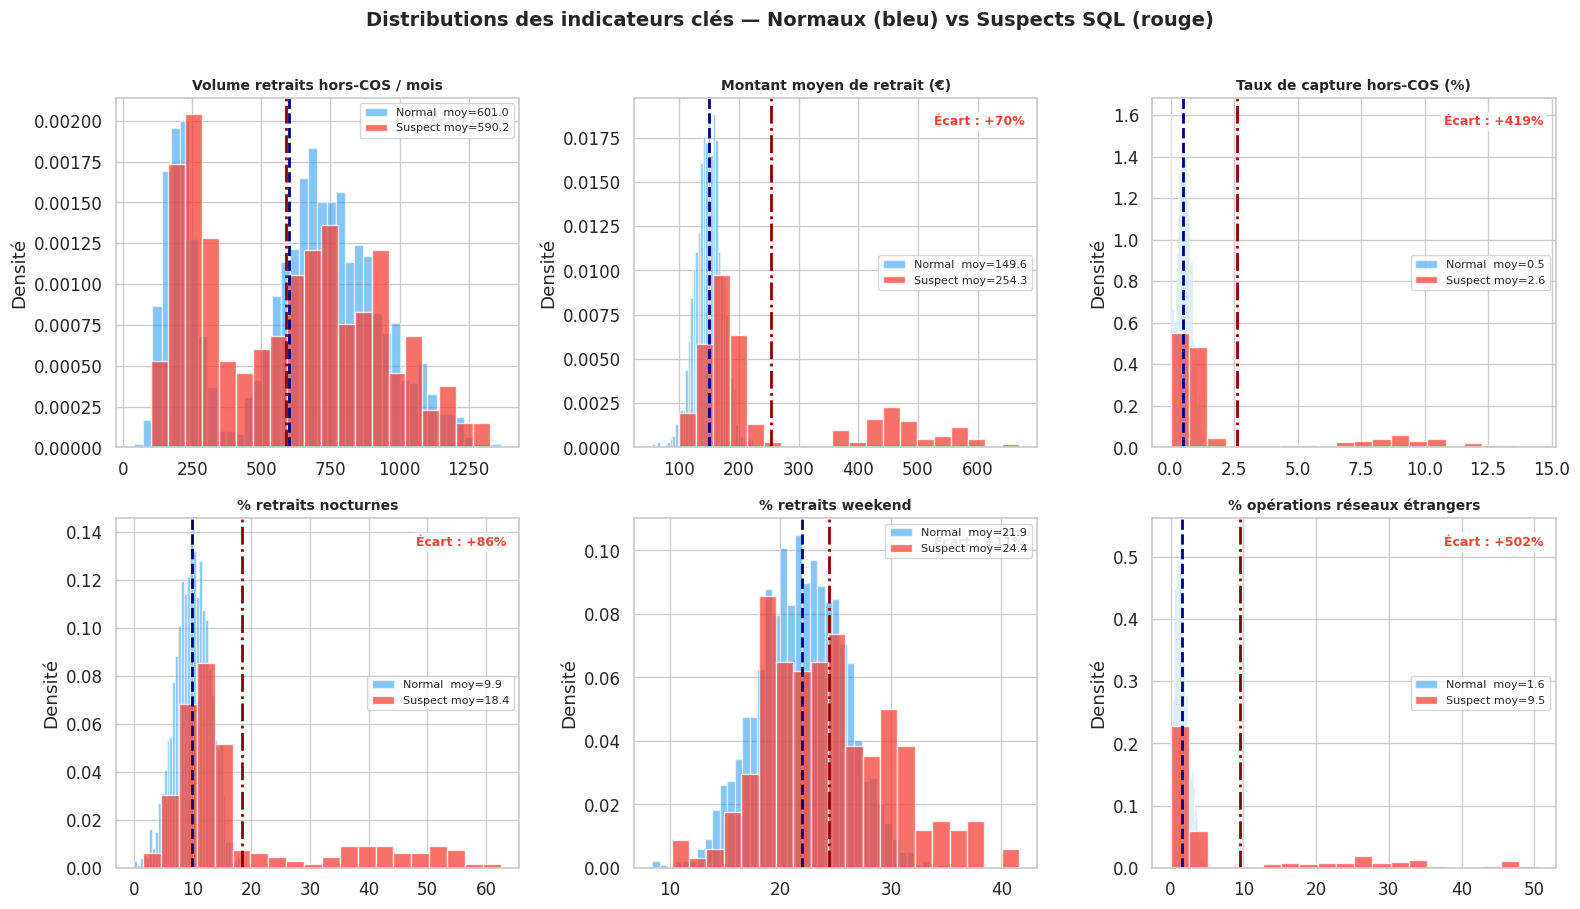

💡 Plus l'écart est grand, plus la variable est discriminante pour la détection.


In [5]:
# ── 5.1 Distributions : normaux vs suspects — où se situe la rupture ? ───────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distributions des indicateurs clés — Normaux (bleu) vs Suspects SQL (rouge)',
             fontsize=14, fontweight='bold', y=1.01)

variables = [
    ('ret_nb_horscos',   'Volume retraits hors-COS / mois'),
    ('ret_montant_moyen','Montant moyen de retrait (€)'),
    ('taux_capture_pct', 'Taux de capture hors-COS (%)'),
    ('ret_pct_nuit',     '% retraits nocturnes'),
    ('ret_pct_weekend',  '% retraits weekend'),
    ('pct_reseaux_etrangers','% opérations réseaux étrangers'),
]

for ax, (col, titre) in zip(axes.flatten(), variables):
    if col not in df.columns: continue
    norm = df[df['flag_atypique']==0][col].dropna()
    atyp = df[df['flag_atypique']==1][col].dropna()
    ax.hist(norm, bins=40, color=COULEUR_NORMAL,   alpha=0.55, density=True,
            label=f'Normal  moy={norm.mean():.1f}')
    ax.hist(atyp, bins=20, color=COULEUR_ANOMALIE, alpha=0.75, density=True,
            label=f'Suspect moy={atyp.mean():.1f}')
    ax.axvline(norm.mean(), color='navy',   lw=2, ls='--')
    ax.axvline(atyp.mean(), color='darkred',lw=2, ls='-.')
    # Annotation écart
    if norm.mean() > 0:
        ecart = (atyp.mean()-norm.mean())/norm.mean()*100
        ax.text(0.97, 0.95, f'Écart : {ecart:+.0f}%',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=9, fontweight='bold',
                color=COULEUR_ANOMALIE if abs(ecart)>20 else 'grey',
                bbox={'boxstyle':'round,pad=0.2','fc':'white','alpha':0.8})
    ax.set_title(titre, fontweight='bold', fontsize=10)
    ax.set_ylabel('Densité')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('distributions_gab.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Plus l\'écart est grand, plus la variable est discriminante pour la détection.')


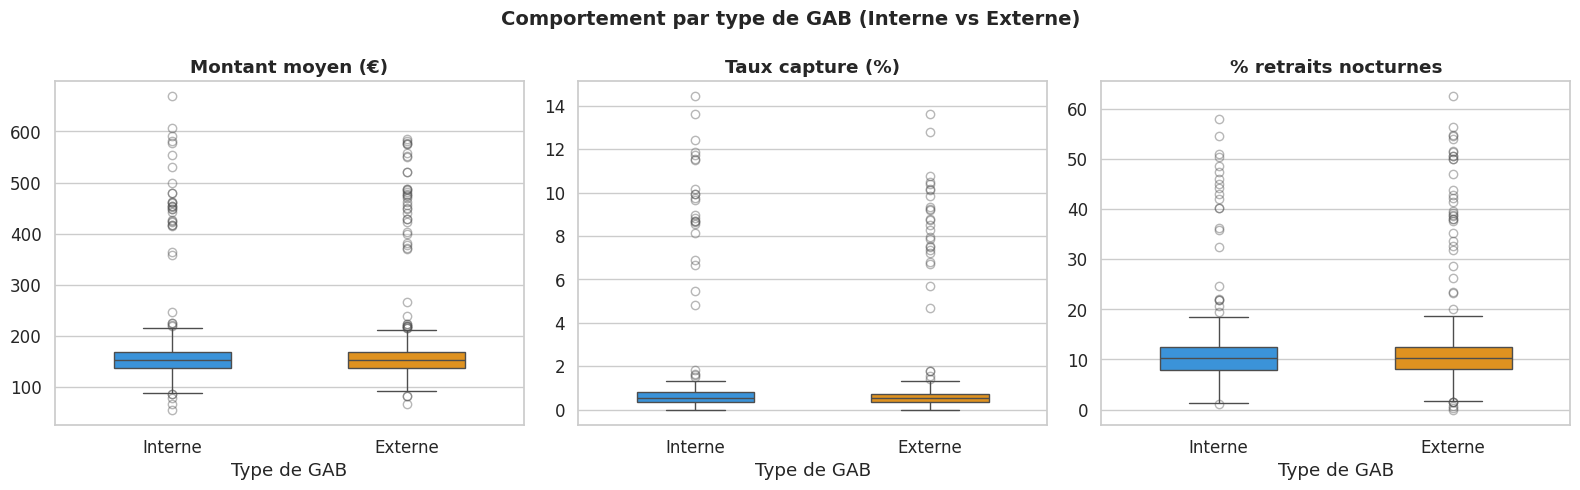

💡 Les GAB Internes (en agence) ont des profils différents des GAB Externes → à comparer séparément.


In [6]:
# ── 5.2 Boxplots par type GAB ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comportement par type de GAB (Interne vs Externe)', fontsize=14, fontweight='bold')

metriques_box = [
    ('ret_montant_moyen', 'Montant moyen (€)'),
    ('taux_capture_pct',  'Taux capture (%)'),
    ('ret_pct_nuit',      '% retraits nocturnes'),
]

for ax, (col, titre) in zip(axes, metriques_box):
    sns.boxplot(data=df, x='type_gab_e_i', y=col, ax=ax,
                palette={'Interne': COULEUR_NORMAL, 'Externe': COULEUR_ACCENT},
                width=0.5, flierprops={'marker':'o','alpha':0.4})
    ax.set_title(titre, fontweight='bold')
    ax.set_xlabel('Type de GAB')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('boxplots_type_gab.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Les GAB Internes (en agence) ont des profils différents des GAB Externes → à comparer séparément.')

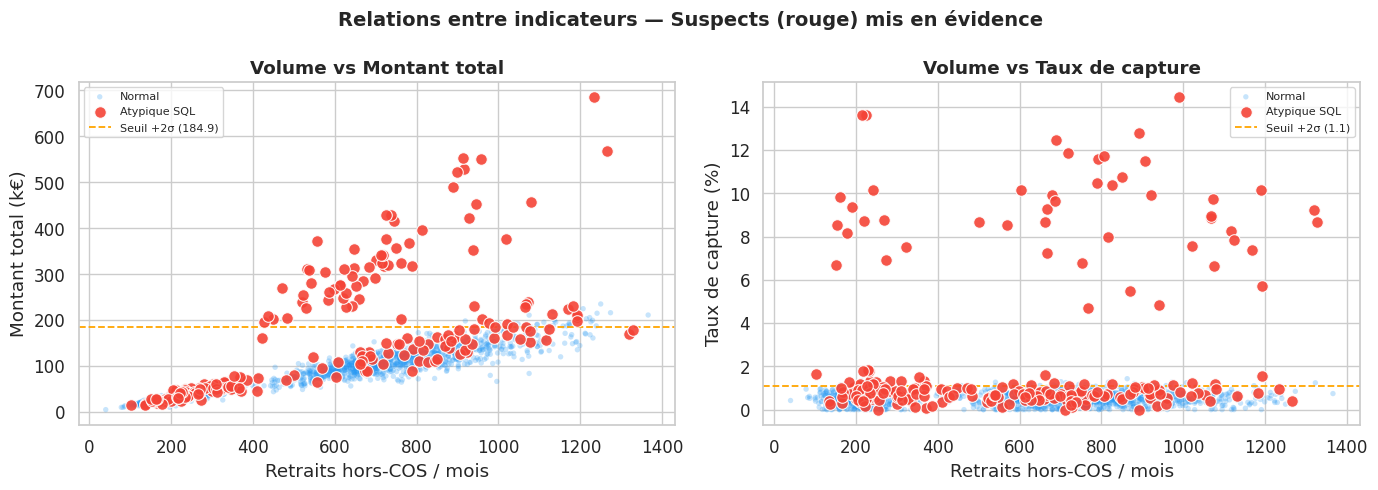

💡 Les points rouges au-dessus du seuil orange sont les cas les plus suspects.


In [7]:
# ── 5.3 Scatter : volume vs montants et capture — suspects mis en évidence ─────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Relations entre indicateurs — Suspects (rouge) mis en évidence',
             fontsize=14, fontweight='bold')

coul = df['flag_atypique'].map({0:COULEUR_NORMAL, 1:COULEUR_ANOMALIE})
sz   = df['flag_atypique'].map({0:15, 1:60})
alph = df['flag_atypique'].map({0:0.25, 1:0.85})

for ax, ycol, ylabel, titre in [
    (axes[0], 'ret_montant_total', 'Montant total (k€)', 'Volume vs Montant total'),
    (axes[1], 'taux_capture_pct',  'Taux de capture (%)',  'Volume vs Taux de capture'),
]:
    yvals = df[ycol]/1000 if 'total' in ycol else df[ycol]
    # Normaux d'abord
    m0 = df['flag_atypique']==0
    m1 = df['flag_atypique']==1
    ax.scatter(df.loc[m0,'ret_nb_horscos'], yvals[m0],
               c=COULEUR_NORMAL, s=15, alpha=0.25, edgecolors='none', label='Normal')
    ax.scatter(df.loc[m1,'ret_nb_horscos'], yvals[m1],
               c=COULEUR_ANOMALIE, s=70, alpha=0.90, edgecolors='white', lw=0.8,
               zorder=5, label='Atypique SQL')
    # Seuil +2σ
    seuil = yvals[m0].mean() + 2*yvals[m0].std()
    ax.axhline(seuil, color='orange', ls='--', lw=1.3,
               label=f'Seuil +2σ ({seuil:.1f})')
    ax.set_xlabel('Retraits hors-COS / mois'); ax.set_ylabel(ylabel)
    ax.set_title(titre, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('scatter_indicateurs.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Les points rouges au-dessus du seuil orange sont les cas les plus suspects.')


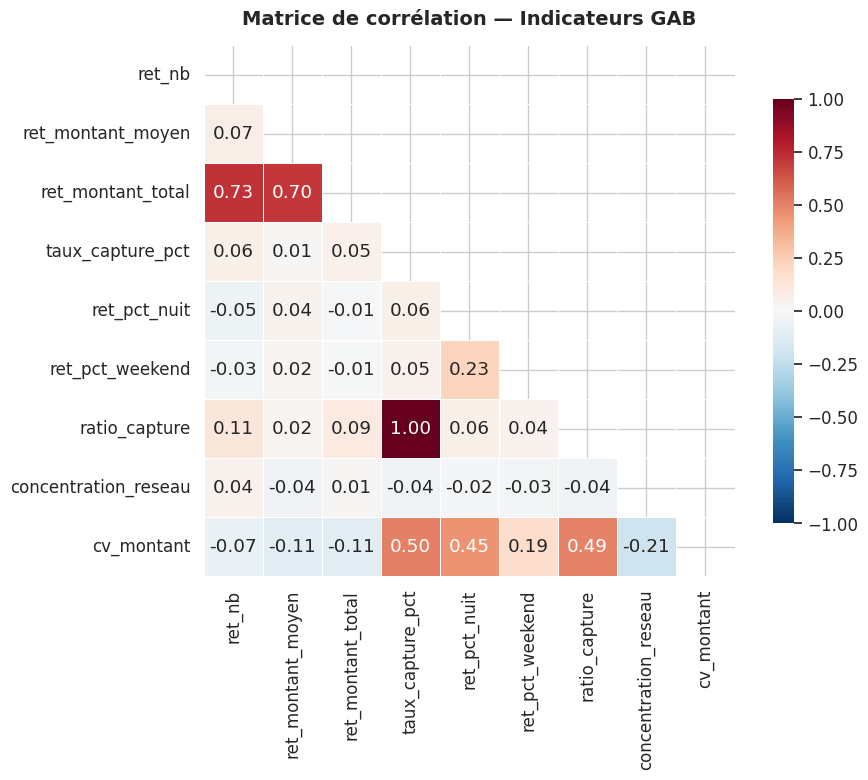

💡 Des corrélations fortes entre variables peuvent indiquer un comportement cohérent (normal) ou anormal.


In [8]:
# ── 5.4 Heatmap de corrélation ─────────────────────────────────────────────────
features_corr = ['ret_nb','ret_montant_moyen','ret_montant_total',
                 'taux_capture_pct','ret_pct_nuit','ret_pct_weekend',
                 'ratio_capture','concentration_reseau','cv_montant']

corr_matrix = df[features_corr].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Matrice de corrélation — Indicateurs GAB', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('heatmap_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Des corrélations fortes entre variables peuvent indiquer un comportement cohérent (normal) ou anormal.')

## 5bis. 🌍 Focus Réseaux Étrangers (JCB, Amex, Diners)

### Pourquoi surveiller les réseaux étrangers ?

Les cartes **JCB** (Japon), **Amex** et **Diners/Discovery** sont utilisées majoritairement par des **touristes étrangers**.  
Une activité anormalement élevée sur ces réseaux dans un GAB donné peut signaler :
- Un GAB situé dans une zone touristique à forte fréquentation étrangère *(contexte normal)*
- Une utilisation frauduleuse concentrée sur un seul automate *(signal d'alerte)*

La **cartographie géographique** permet de distinguer ces deux cas.


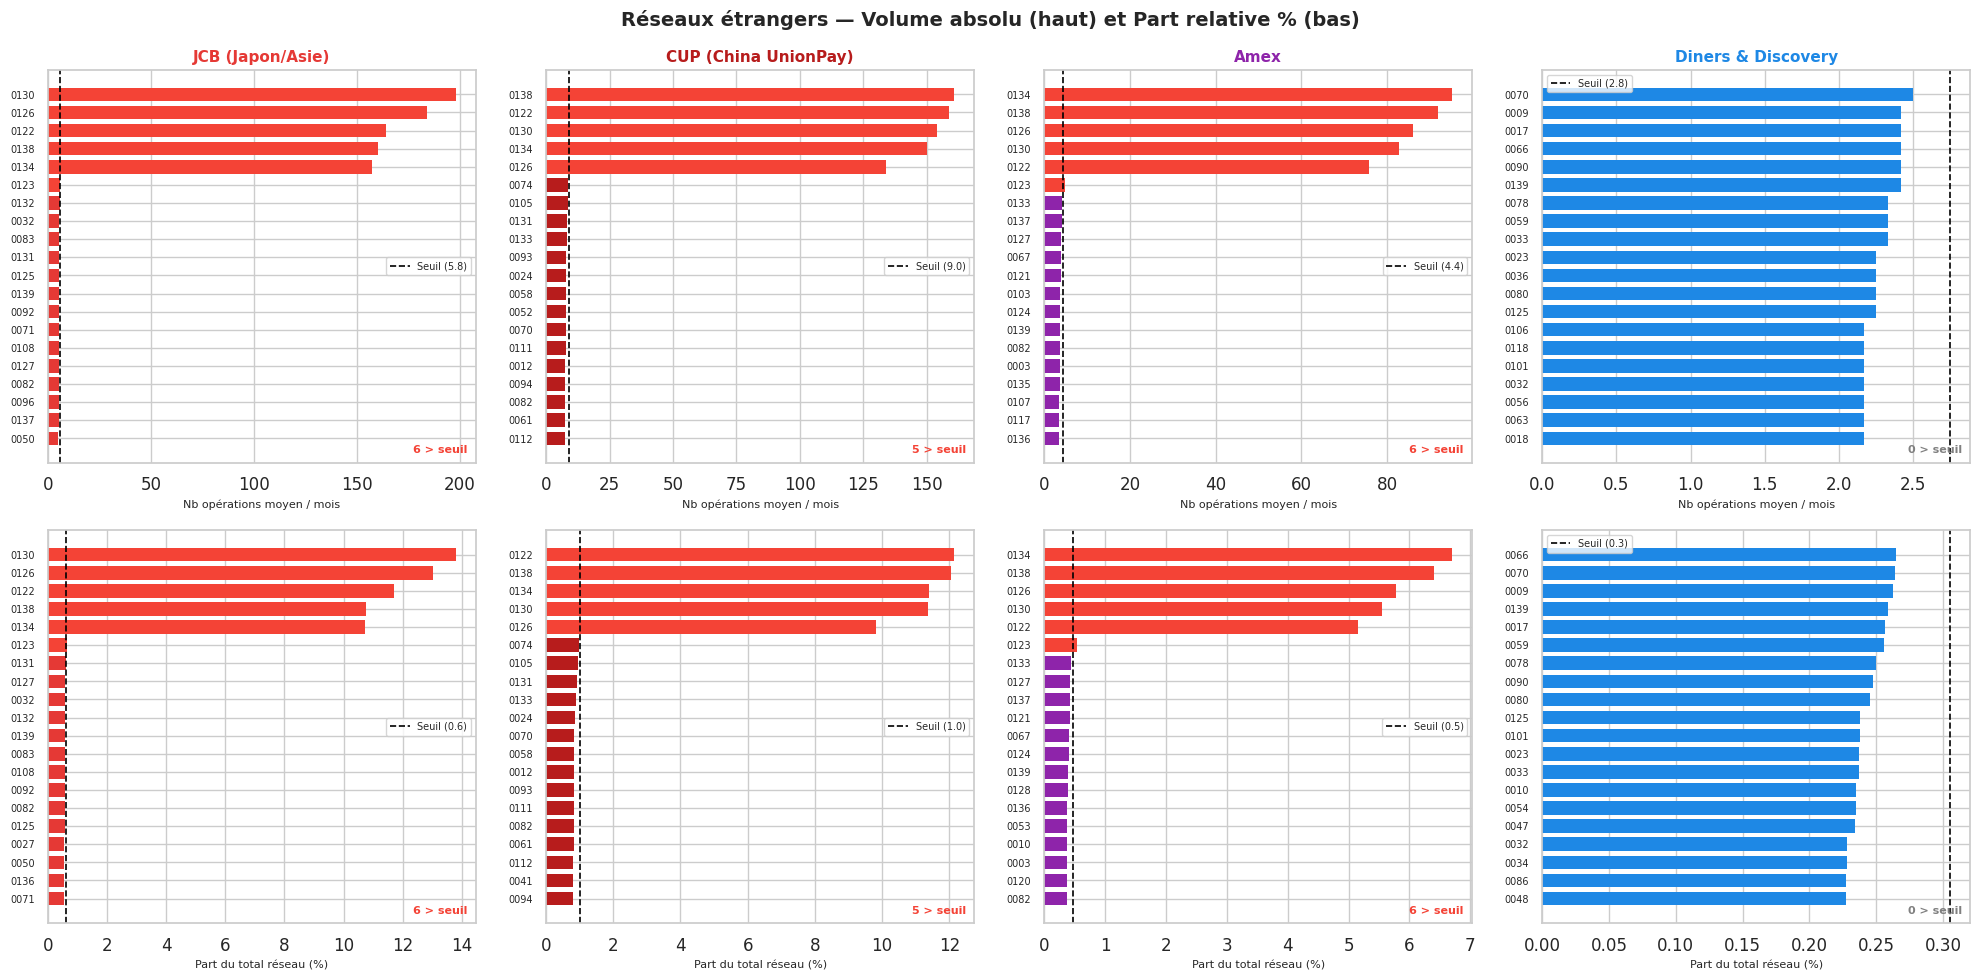

💡 Ligne du haut : volume absolu. Ligne du bas : part relative dans le total réseau.
   Un GAB avec 5 opérations JCB sur 6 opérations totales = bien plus suspect
   qu'un GAB avec 200 JCB sur 10 000 opérations.


In [10]:
# ── 5bis.1 Réseaux étrangers — comparaison normalisée (part vs volume total) ──
# Problème précédent : JCB/Diners quasi-nuls en valeur absolue → graphes plats.
# Solution : on visualise la PART relative (% du total réseau) + valeur absolue
#            en adaptant l'échelle à chaque réseau individuellement.

reseaux_etr = [
    ('nb_ope_reseau_jcb',                      'pct_jcb',  'JCB (Japon/Asie)',     '#E53935'),
    ('nb_ope_reseau_cup',                      'pct_cup',  'CUP (China UnionPay)', '#B71C1C'),
    ('nb_ope_reseau_amex',                     'pct_amex', 'Amex',                 '#8E24AA'),
    ('nb_ope_reseau_carte_diners_et_discovery','pct_carte_diners_et_discovery',
                                                           'Diners & Discovery',   '#1E88E5'),
]
reseaux_etr = [(a,b,c,d) for a,b,c,d in reseaux_etr if a in df.columns]

fig, axes = plt.subplots(2, len(reseaux_etr), figsize=(5*len(reseaux_etr), 10))
if len(reseaux_etr) == 1: axes = [[axes[0]], [axes[1]]]
fig.suptitle('Réseaux étrangers — Volume absolu (haut) et Part relative % (bas)',
             fontsize=14, fontweight='bold')

for col_idx, (col_abs, col_pct, label, color) in enumerate(reseaux_etr):
    gab_abs = df.groupby('num_automate')[col_abs].mean().sort_values(ascending=False)
    gab_pct = df.groupby('num_automate')[col_pct].mean().sort_values(ascending=False) if col_pct in df.columns else gab_abs*0

    for row_idx, (gab_data, ylabel, use_pct) in enumerate([
        (gab_abs, 'Nb opérations moyen / mois', False),
        (gab_pct, 'Part du total réseau (%)',   True),
    ]):
        ax = axes[row_idx][col_idx]
        top = gab_data.head(20)

        # Seuil = médiane + 2 * IQR (plus robuste que moyenne+2σ quand beaucoup de 0)
        q75 = gab_data.quantile(.75); q25 = gab_data.quantile(.25)
        seuil = q75 + 1.5*(q75-q25) if q75 > q25 else gab_data.mean() + 2*gab_data.std()

        if top.max() < 0.01:
            ax.text(0.5, 0.5, 'Données < 0.01 (réseau rare)', ha='center', va='center',
                    transform=ax.transAxes, color='grey', fontsize=10)
            ax.set_title(label if row_idx==0 else '', fontweight='bold', color=color, fontsize=10)
            continue

        couleurs = [COULEUR_ANOMALIE if v > seuil else color for v in top.values]
        ax.barh(range(len(top)), top.values, color=couleurs, edgecolor='none', height=0.75)
        ax.set_yticks(range(len(top)))
        ax.set_yticklabels([str(g).split('_')[-1] for g in top.index], fontsize=7)
        ax.invert_yaxis()

        if seuil > 0:
            ax.axvline(seuil, color='black', ls='--', lw=1.2,
                       label=f'Seuil ({seuil:.1f})')
            ax.legend(fontsize=7)

        ax.set_xlabel(ylabel, fontsize=8)
        if row_idx == 0:
            ax.set_title(label, fontweight='bold', color=color, fontsize=11)
        n_dep = (top.values > seuil).sum()
        ax.text(0.98, 0.02, f'{n_dep} > seuil',
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=8, color=COULEUR_ANOMALIE if n_dep > 0 else 'grey', fontweight='bold')

plt.tight_layout()
plt.savefig('reseaux_etrangers_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Ligne du haut : volume absolu. Ligne du bas : part relative dans le total réseau.')
print('   Un GAB avec 5 opérations JCB sur 6 opérations totales = bien plus suspect')
print('   qu\'un GAB avec 200 JCB sur 10 000 opérations.')


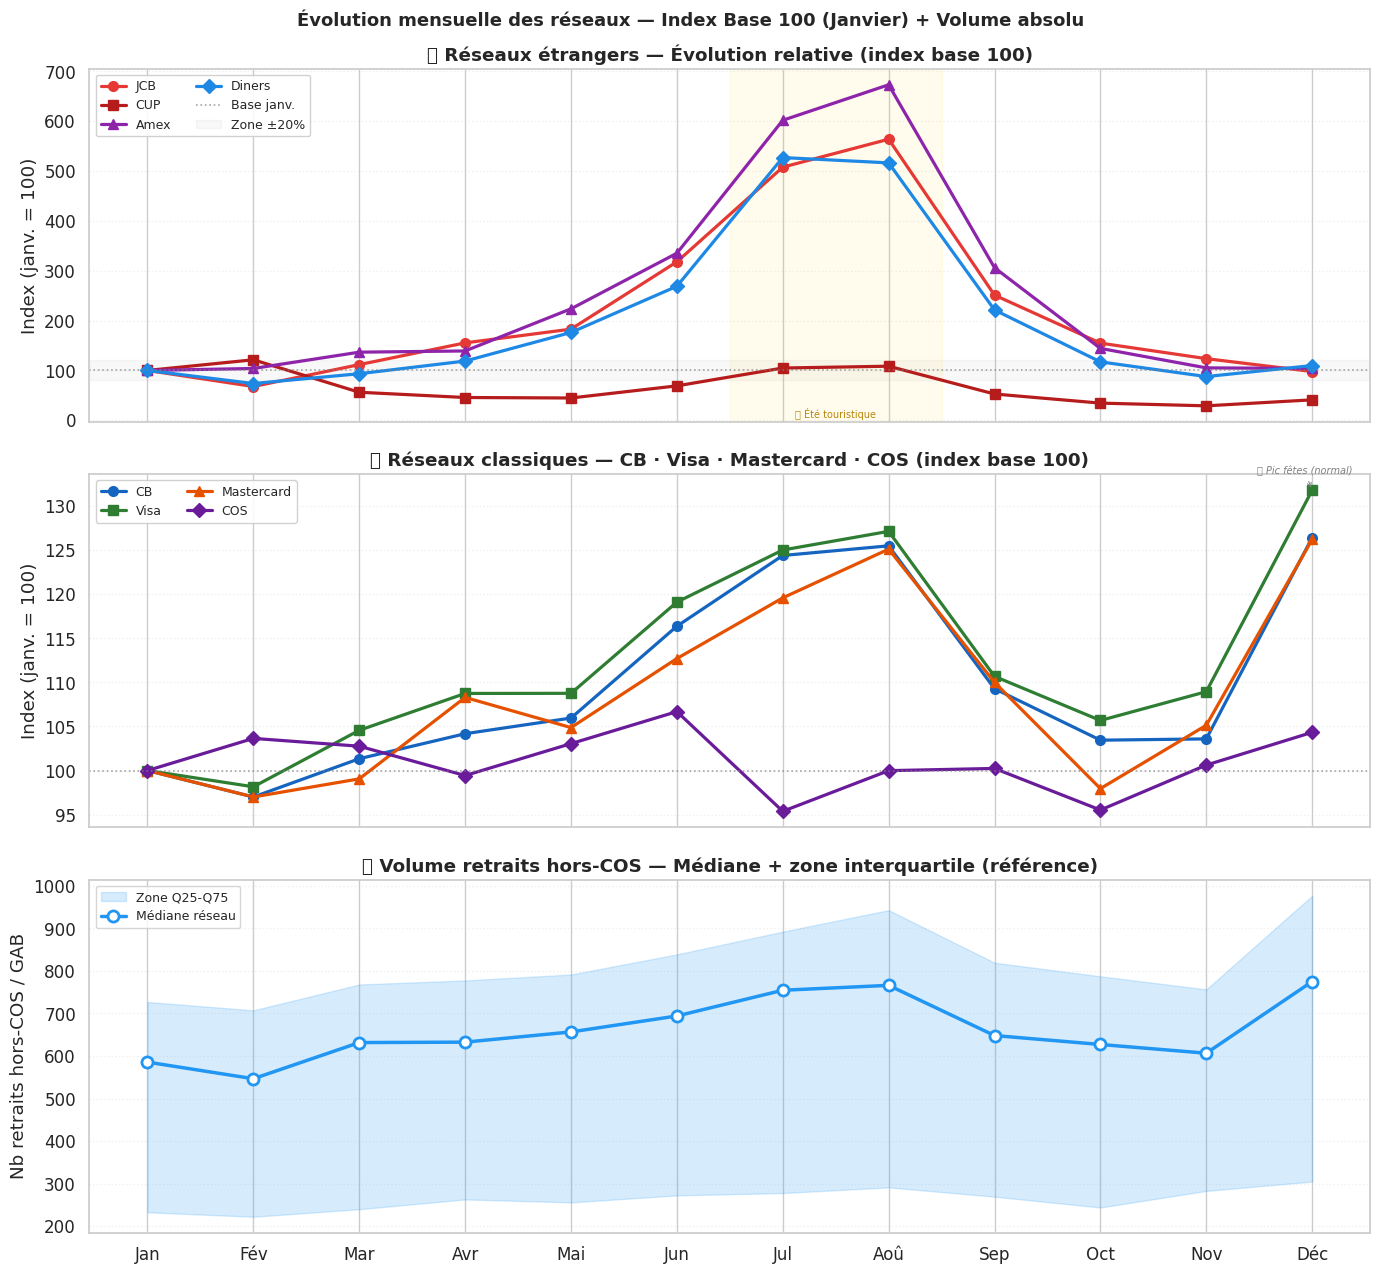

💡 L'index base 100 rend comparables des réseaux de tailles très différentes.
   JCB à 200 = double de janvier  →  signal clair, même si la valeur absolue est faible.


In [13]:
# ── 5bis.2 Évolution temporelle — réseaux étrangers vs classiques ────────────
# Problème précédent : courbes JCB/Diners plates car valeurs absolues trop petites.
# Solution : on trace en INDEX BASE 100 (jan=100) pour comparer les variations
#            indépendamment des niveaux absolus.

MOIS_LABELS = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

etr_def = {
    'nb_ope_reseau_jcb':                       ('JCB',     '#E53935','o-'),
    'nb_ope_reseau_cup':                       ('CUP',     '#B71C1C','s-'),
    'nb_ope_reseau_amex':                      ('Amex',    '#8E24AA','^-'),
    'nb_ope_reseau_carte_diners_et_discovery': ('Diners',  '#1E88E5','D-'),
}
cls_def = {
    'nb_ope_reseau_cb':         ('CB',          '#1565C0','o-'),
    'nb_ope_reseau_visa':       ('Visa',
                                 '#2E7D32','s-'),
    'nb_ope_reseau_mastercard': ('Mastercard',  '#E65100','^-'),
    'nb_ope_reseau_cos':        ('COS',         '#6A1B9A','D-'),
}

etr_def = {k:v for k,v in etr_def.items() if k in df.columns}
cls_def  = {k:v for k,v in cls_def.items() if k in df.columns}

all_cols = list(etr_def)+list(cls_def)+['ret_nb_horscos']
agg      = {c:(c,'mean') for c in all_cols if c in df.columns}
df_temp  = df.groupby('mois').agg(**agg).reset_index()

# Index base 100 (mois 1 = base)
df_idx = df_temp.copy()
for c in list(etr_def)+list(cls_def)+['ret_nb_horscos']:
    if c in df_temp.columns:
        base_val = df_temp.loc[df_temp['mois']==1, c].values
        if len(base_val) > 0 and base_val[0] > 0:
            df_idx[c] = df_temp[c] / base_val[0] * 100
        else:
            df_idx[c] = np.nan

fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)
fig.suptitle('Évolution mensuelle des réseaux — Index Base 100 (Janvier) + Volume absolu',
             fontsize=13, fontweight='bold')

# ── Graphique 1 : Réseaux étrangers en index base 100 ────────────────────────
ax1 = axes[0]
has_data = False
for col,(lbl,col_hex,mk) in etr_def.items():
    if col not in df_idx.columns or df_idx[col].isna().all(): continue
    if df_temp[col].max() < 0.5: continue   # réseau inexistant, skip
    has_data = True
    ax1.plot(df_idx['mois'], df_idx[col], mk, color=col_hex, lw=2.3, ms=7, label=lbl)

if has_data:
    ax1.axhline(100, color='grey', ls=':', lw=1.2, alpha=0.7, label='Base janv.')
    ax1.axhspan(80,120, alpha=0.05, color='grey', label='Zone ±20%')
    ax1.axvspan(6.5,8.5, alpha=0.07, color='gold')
    ax1.text(7.5, ax1.get_ylim()[0]*1.05 if ax1.get_ylim()[0]>0 else 5,
             '🌞 Été touristique', ha='center', fontsize=7, color='#B8860B')
    ax1.set_title('🌍 Réseaux étrangers — Évolution relative (index base 100)', fontweight='bold')
    ax1.set_ylabel('Index (janv. = 100)')
    ax1.legend(loc='upper left', fontsize=9, ncol=2, framealpha=0.9)
else:
    ax1.text(0.5,0.5,'Réseaux étrangers : données insuffisantes dans ce dataset',
             ha='center',va='center',transform=ax1.transAxes,color='grey',fontsize=11)

# ── Graphique 2 : Réseaux classiques en index base 100 ───────────────────────
ax2 = axes[1]
for col,(lbl,col_hex,mk) in cls_def.items():
    if col not in df_idx.columns or df_idx[col].isna().all(): continue
    ax2.plot(df_idx['mois'], df_idx[col], mk, color=col_hex, lw=2.3, ms=7, label=lbl)
ax2.axhline(100, color='grey', ls=':', lw=1.2, alpha=0.7)
if len(df_temp) == 12:
    dec_max = max(df_idx.loc[df_idx['mois']==12, c].values[0]
                  for c in cls_def if c in df_idx.columns and not np.isnan(df_idx.loc[df_idx['mois']==12,c].values[0]))
    ax2.annotate('🎄 Pic fêtes (normal)', xy=(12, dec_max),
                 xytext=(-40,12), textcoords='offset points',
                 fontsize=7, color='grey', style='italic',
                 arrowprops={'arrowstyle':'->','color':'grey','lw':0.7})
ax2.set_title('💳 Réseaux classiques — CB · Visa · Mastercard · COS (index base 100)', fontweight='bold')
ax2.set_ylabel('Index (janv. = 100)')
ax2.legend(loc='upper left', fontsize=9, ncol=2, framealpha=0.9)

# ── Graphique 3 : Volume absolu hors-COS (médiane réseau) ────────────────────
ax3 = axes[2]
vol_med = df.groupby('mois')['ret_nb_horscos'].median()
vol_p25 = df.groupby('mois')['ret_nb_horscos'].quantile(.25)
vol_p75 = df.groupby('mois')['ret_nb_horscos'].quantile(.75)
ax3.fill_between(vol_med.index, vol_p25, vol_p75, alpha=0.18, color=COULEUR_NORMAL, label='Zone Q25-Q75')
ax3.plot(vol_med.index, vol_med, 'o-', color=COULEUR_NORMAL, lw=2.5, ms=8,
         markerfacecolor='white', markeredgewidth=2, label='Médiane réseau')
ax3.set_title('📊 Volume retraits hors-COS — Médiane + zone interquartile (référence)', fontweight='bold')
ax3.set_ylabel('Nb retraits hors-COS / GAB')
ax3.legend(fontsize=9)

for ax in axes:
    ax.set_xticks(range(1,13)); ax.set_xticklabels(MOIS_LABELS)
    ax.grid(axis='y', alpha=0.3, linestyle=':')

plt.tight_layout()
plt.savefig('reseaux_temporel.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 L\'index base 100 rend comparables des réseaux de tailles très différentes.')
print('   JCB à 200 = double de janvier  →  signal clair, même si la valeur absolue est faible.')


In [15]:
# ── 5bis.3 Carte géographique des réseaux étrangers (JCB + CUP + Amex + Diners)
cp_col = 'code_postale_emplacement' if 'code_postale_emplacement' in df.columns else 'code_postal'

agg_etr = {
    'latitude':   ('latitude',  'first'),
    'longitude':  ('longitude', 'first'),
    'cp':         (cp_col,      'first'),
    'contexte':   ('contexte_geo','first'),
    'flag_max':   ('flag_atypique','max'),
    'ret_nb_moy': ('ret_nb_horscos','mean'),
}
for col in ['nb_ope_reseau_jcb','nb_ope_reseau_cup','nb_ope_reseau_amex',
            'nb_ope_reseau_carte_diners_et_discovery']:
    if col in df.columns:
        nm = col.replace('nb_ope_reseau_','') + '_moy'
        agg_etr[nm] = (col, 'mean')

df_geo_etr = df.groupby('num_automate').agg(**agg_etr).reset_index()

etr_cols_disp = [c for c in df_geo_etr.columns if c.endswith('_moy') and c != 'ret_nb_moy']
df_geo_etr['nb_etranger_total'] = df_geo_etr[etr_cols_disp].sum(axis=1)
df_geo_etr['statut'] = df_geo_etr['flag_max'].map({0:'Normal', 1:'Atypique SQL'})

# Scaling logarithmique du marker size pour éviter que tout soit égal
df_geo_etr['size_plot'] = np.log1p(df_geo_etr['nb_etranger_total']) * 3 + 2

hover = {'cp':True,'contexte':True,'ret_nb_moy':':.0f','nb_etranger_total':':.1f',
         'statut':True,'latitude':False,'longitude':False,'size_plot':False}
for c in etr_cols_disp:
    hover[c] = ':.1f'

fig_etr = px.scatter_mapbox(
    df_geo_etr,
    lat='latitude', lon='longitude',
    color='nb_etranger_total',
    size='size_plot',
    size_max=30,
    color_continuous_scale=['#E8F5E9','#FFEB3B','#FF5722','#B71C1C'],
    hover_name='num_automate',
    hover_data=hover,
    mapbox_style='carto-positron',
    zoom=3, center={'lat':30,'lon':-10},
    title='🌍 Intensité réseaux étrangers (JCB + CUP + Amex + Diners) — log scale',
    height=580,
)
fig_etr.update_layout(margin={'r':0,'t':45,'l':0,'b':0},
                      coloraxis_colorbar_title='Nb opérations<br>étrangères/mois')
fig_etr.show()
print('💡 Taille log-scalée : les petites valeurs restent visibles, les grandes ressortent.')
print('   DOM-TOM inclus — vérifier si l\'activité étrangère est cohérente avec le territoire.')


💡 Taille log-scalée : les petites valeurs restent visibles, les grandes ressortent.
   DOM-TOM inclus — vérifier si l'activité étrangère est cohérente avec le territoire.


## 6. 📅 Analyse Temporelle

### Le comportement des GAB évolue-t-il dans le temps ?

La **saisonnalité** est un facteur clé : une hausse d'activité en décembre est normale.  
Ce qui n'est **pas** normal : une hausse isolée sur un seul automate, hors saison.

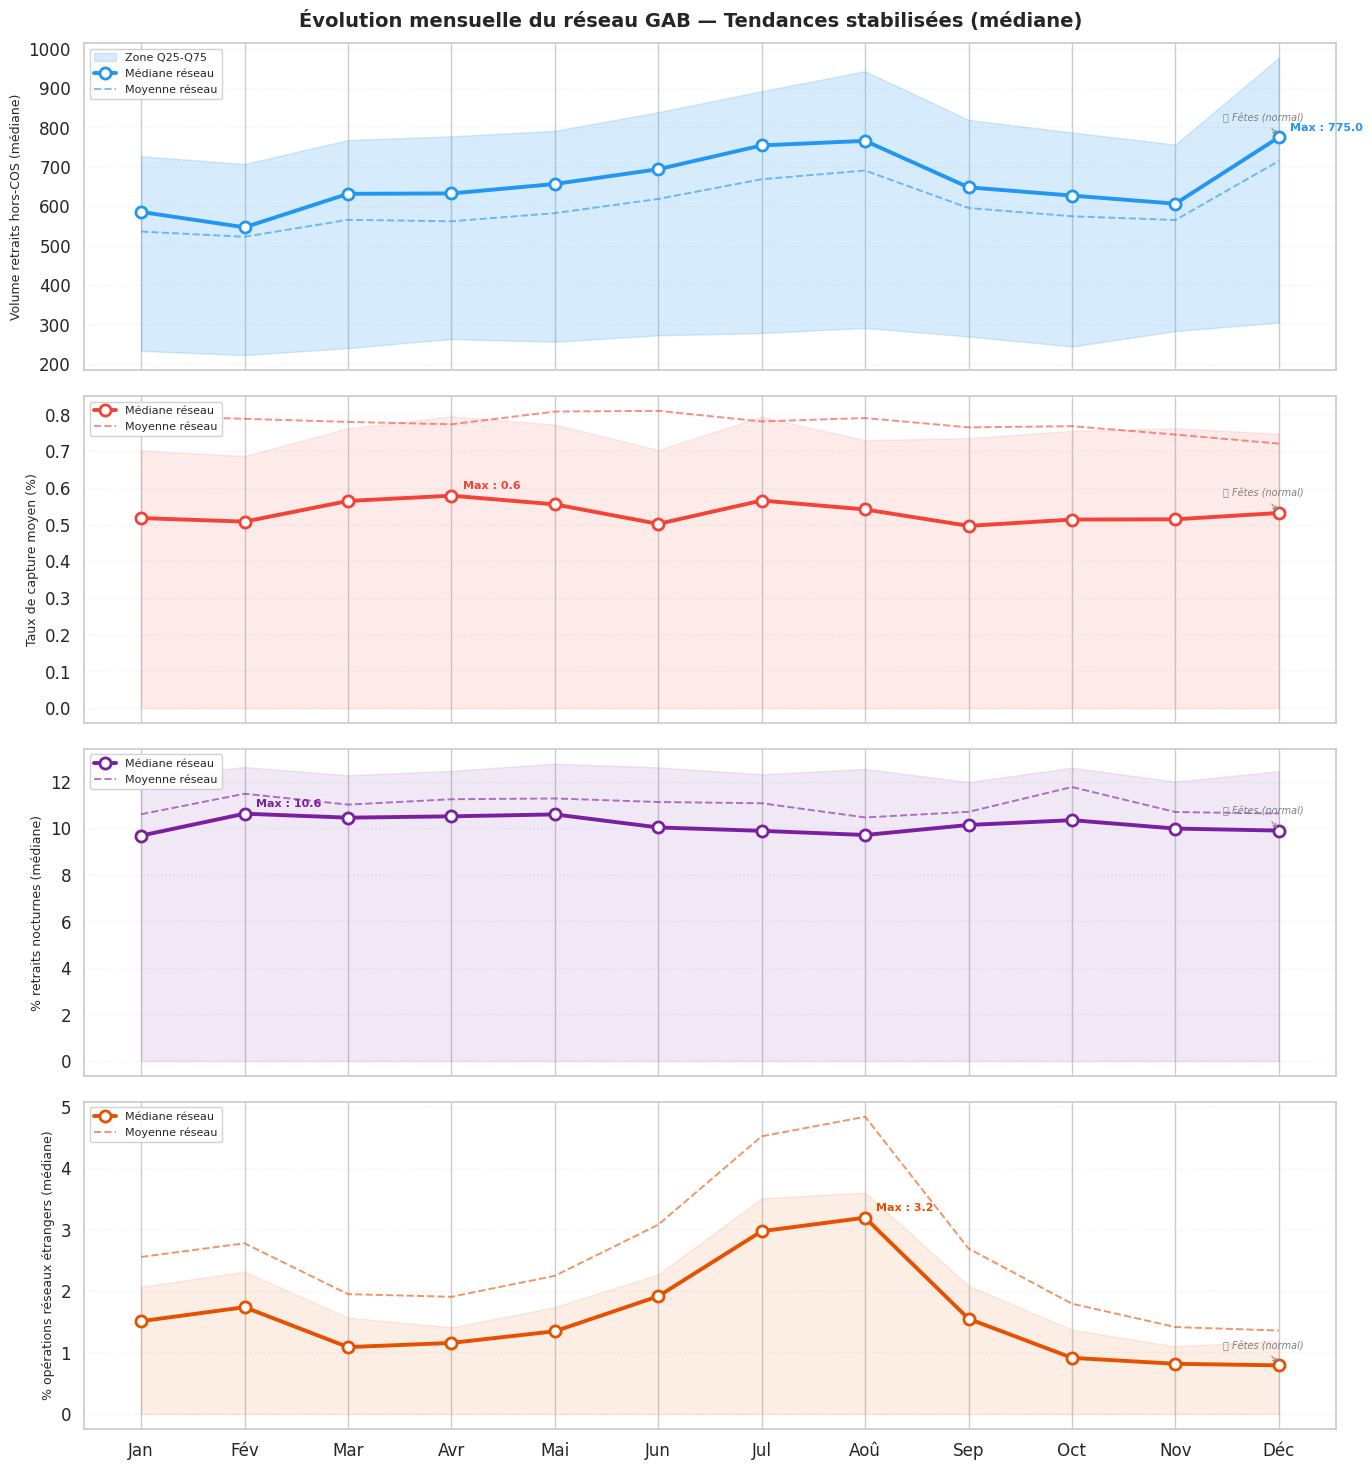


📅 % de GAB atypiques (flag SQL) par mois :
    Jan : ██████                    12.9%  (18 GAB)  ⚠️
    Fév : ██████                    12.9%  (18 GAB)  ⚠️
    Mar : ██████                    12.9%  (18 GAB)  ⚠️
    Avr : ██████                    12.9%  (18 GAB)  ⚠️
    Mai : ██████                    12.9%  (18 GAB)  ⚠️
    Jun : ██████                    12.9%  (18 GAB)  ⚠️
    Jul : ██████                    12.9%  (18 GAB)  ⚠️
    Aoû : ██████                    12.9%  (18 GAB)  ⚠️
    Sep : ██████                    12.9%  (18 GAB)  ⚠️
    Oct : ██████                    12.9%  (18 GAB)  ⚠️
    Nov : ██████                    12.9%  (18 GAB)  ⚠️
    Déc : ██████                    12.9%  (18 GAB)  ⚠️

💡 Médiane vs Moyenne :
   La médiane est moins sensible aux outliers → courbe plus stable et plus représentative.
   Un écart important médiane/moyenne signale des GAB très atypiques ce mois-là.


In [16]:
# ── 6.1 Évolution mensuelle du réseau — vue globale stabilisée ──────────────
# Agrégation sur la médiane par mois (plus robuste que la moyenne face aux outliers)
# ce qui donne des courbes plus stables et plus interprétables

MOIS_LABELS = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

df_temps = df.groupby('mois').agg(
    ret_nb_med      = ('ret_nb_horscos',       'median'),
    ret_nb_moy      = ('ret_nb_horscos',       'mean'),
    ret_nb_p75      = ('ret_nb_horscos',       lambda x: x.quantile(.75)),
    ret_nb_p25      = ('ret_nb_horscos',       lambda x: x.quantile(.25)),
    taux_cap_med    = ('taux_capture_pct',     'median'),
    taux_cap_moy    = ('taux_capture_pct',     'mean'),
    taux_cap_p75    = ('taux_capture_pct',     lambda x: x.quantile(.75)),
    pct_nuit_med    = ('ret_pct_nuit',         'median'),
    pct_nuit_moy    = ('ret_pct_nuit',         'mean'),
    pct_nuit_p75    = ('ret_pct_nuit',         lambda x: x.quantile(.75)),
    pct_etr_med     = ('pct_reseaux_etrangers','median'),
    pct_etr_moy     = ('pct_reseaux_etrangers','mean'),
    pct_etr_p75     = ('pct_reseaux_etrangers',lambda x: x.quantile(.75)),
    nb_atypiques    = ('flag_atypique',        'sum'),
    n_gab           = ('num_automate',         'count'),
).reset_index()

df_temps['pct_atypiques'] = (df_temps['nb_atypiques'] / df_temps['n_gab'] * 100).round(1)

fig, axes = plt.subplots(4, 1, figsize=(14, 15), sharex=True)
fig.suptitle('Évolution mensuelle du réseau GAB — Tendances stabilisées (médiane)',
             fontsize=14, fontweight='bold')

series = [
    (axes[0], 'ret_nb_med',   'ret_nb_moy',   'ret_nb_p25',   'ret_nb_p75',
     COULEUR_NORMAL,   '#E3F2FD', 'Volume retraits hors-COS (médiane)'),
    (axes[1], 'taux_cap_med', 'taux_cap_moy',  None,           'taux_cap_p75',
     COULEUR_ANOMALIE, '#FFEBEE', 'Taux de capture moyen (%)'),
    (axes[2], 'pct_nuit_med', 'pct_nuit_moy',  None,           'pct_nuit_p75',
     '#7B1FA2',        '#F3E5F5', '% retraits nocturnes (médiane)'),
    (axes[3], 'pct_etr_med',  'pct_etr_moy',   None,           'pct_etr_p75',
     '#E65100',        '#FFF3E0', '% opérations réseaux étrangers (médiane)'),
]

for ax, col_med, col_moy, col_p25, col_p75, color, fill_color, label in series:
    x = df_temps['mois']

    # Bande interquartile (Q25-Q75) — zone de normalité
    if col_p25 and col_p25 in df_temps.columns:
        ax.fill_between(x, df_temps[col_p25], df_temps[col_p75],
                        alpha=0.18, color=color, label='Zone Q25-Q75')
    elif col_p75 in df_temps.columns:
        ax.fill_between(x, 0, df_temps[col_p75],
                        alpha=0.10, color=color)

    # Médiane (ligne principale — plus stable)
    ax.plot(x, df_temps[col_med], 'o-', color=color, lw=2.8, ms=8,
            markerfacecolor='white', markeredgewidth=2, label='Médiane réseau', zorder=3)

    # Moyenne en pointillé (pour comparaison)
    ax.plot(x, df_temps[col_moy], '--', color=color, lw=1.4, alpha=0.6,
            label='Moyenne réseau', zorder=2)

    # Annotation max
    idx_max = df_temps[col_med].idxmax()
    ax.annotate(f'Max : {df_temps[col_med].max():.1f}',
                xy=(x[idx_max], df_temps[col_med][idx_max]),
                xytext=(8, 5), textcoords='offset points',
                fontsize=8, color=color, fontweight='bold')

    # Annotation décembre
    if 12 in x.values:
        dec_val = df_temps.loc[df_temps['mois']==12, col_med].values[0]
        ax.annotate('🎄 Fêtes (normal)', xy=(12, dec_val),
                    xytext=(-40, 12), textcoords='offset points',
                    fontsize=7, color='grey', style='italic',
                    arrowprops={'arrowstyle':'->','color':'grey','lw':0.7})

    ax.set_ylabel(label, fontsize=9)
    ax.legend(fontsize=8, loc='upper left', framealpha=0.9)
    ax.grid(axis='y', alpha=0.3, linestyle=':')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MOIS_LABELS)

plt.tight_layout()
plt.savefig('evolution_temporelle.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 6.2 Identification des mois atypiques ────────────────────────────────────
print('\n📅 % de GAB atypiques (flag SQL) par mois :')
for _, row in df_temps.iterrows():
    nb_a  = int(row['nb_atypiques'])
    pct_a = row['pct_atypiques']
    barre = '█' * int(pct_a / 2)
    flag  = '  ⚠️' if pct_a > 10 else ''
    print(f'   {MOIS_LABELS[int(row["mois"])-1]:>4} : {barre:<25} {pct_a:.1f}%  ({nb_a} GAB){flag}')
print('\n💡 Médiane vs Moyenne :')
print('   La médiane est moins sensible aux outliers → courbe plus stable et plus représentative.')
print('   Un écart important médiane/moyenne signale des GAB très atypiques ce mois-là.')

## 7. 🗺️ Analyse Géographique

La localisation d'un GAB influence fortement son comportement.  
Un GAB en centre-ville traite naturellement plus de retraits qu'un GAB rural.  
La carte nous permet de **contextualiser** chaque anomalie géographiquement.

In [17]:
# ── 7.1 Carte principale — anomalies et contexte géographique ───────────────
cp_col = 'code_postale_emplacement' if 'code_postale_emplacement' in df.columns else 'code_postal'

agg_geo = {
    'longitude':         ('longitude',           'first'),
    'latitude':          ('latitude',            'first'),
    'ret_nb_moyen':      ('ret_nb_horscos',      'mean'),
    'taux_cap_moyen':    ('taux_capture_pct',    'mean'),
    'type_gab':          ('type_gab_e_i',        'first'),
    'cp':                (cp_col,                'first'),
    'contexte_geo':      ('contexte_geo',        'first'),
    'is_dom_tom':        ('is_dom_tom',          'max'),
    'pct_etranger':      ('pct_reseaux_etrangers','mean'),
    'flag_max':          ('flag_atypique',       'max'),
    'nb_mois_atypiques': ('flag_atypique',       'sum'),
    'score_risque_moy':  ('score_risque',        'mean') if 'score_risque' in df.columns else ('flag_atypique','mean'),
}

df_geo = df.groupby('num_automate').agg(**agg_geo).reset_index()
df_geo['statut'] = df_geo['flag_max'].map({0:'✅ Normal', 1:'🔴 Atypique'})

# Scaling taille : log pour les normaux, taille fixe forte pour les atypiques
df_geo['size_marker'] = np.where(
    df_geo['flag_max'] == 1,
    np.log1p(df_geo['ret_nb_moyen']) * 4 + 15,   # atypiques : plus grand
    np.log1p(df_geo['ret_nb_moyen']) * 2 + 4      # normaux   : discret
)

hover_data = {
    'cp':               True,
    'contexte_geo':     True,
    'type_gab':         True,
    'ret_nb_moyen':     ':.0f',
    'taux_cap_moyen':   ':.2f',
    'nb_mois_atypiques':True,
    'pct_etranger':     ':.1f',
    'statut':           False,
    'latitude':         False,
    'longitude':        False,
    'size_marker':      False,
}

fig_map = px.scatter_mapbox(
    df_geo,
    lat='latitude', lon='longitude',
    color='statut',
    color_discrete_map={'✅ Normal': '#90CAF9', '🔴 Atypique': '#C62828'},
    size='size_marker',
    size_max=28,
    opacity=df_geo['flag_max'].map({0:0.5, 1:1.0}),
    hover_name='num_automate',
    hover_data=hover_data,
    mapbox_style='carto-positron',
    zoom=3, center={'lat': 25.0, 'lon': -10.0},
    title='🗺️ Réseau GAB — Anomalies géolocalisées (rouge = atypique, bleu clair = normal)',
    height=620,
)
fig_map.update_layout(margin={'r':0,'t':45,'l':0,'b':0}, legend_title_text='Statut')
fig_map.show()

print('📊 Répartition par contexte géographique :')
print(df_geo.groupby(['contexte_geo','statut']).size().unstack(fill_value=0).to_string())
print()
print('💡 Symboles identiques mais taille + opacité renforcées pour les atypiques.')
print('   Guyane / DOM-TOM : faible volume = NORMAL — ne pas confondre avec anomalie.')


📊 Répartition par contexte géographique :
statut        ✅ Normal  🔴 Atypique
contexte_geo                      
Guadeloupe          11           1
Guyane              11           3
Métropole           85          11
Réunion              8           2
Saint-Martin         7           1

💡 Symboles identiques mais taille + opacité renforcées pour les atypiques.
   Guyane / DOM-TOM : faible volume = NORMAL — ne pas confondre avec anomalie.


## 8. 🤖 Modélisation — Détection d'Anomalies

### Pourquoi l'Isolation Forest ?

| Modèle | Principe | Adapté ici ? |
|---|---|---|
| **Isolation Forest** | Isole les points rares par partitions aléatoires | ✅ Oui — rapide, robuste, interprétable |
| Local Outlier Factor | Densité locale vs voisins | ⚠️ Lent sur grands datasets |
| One-Class SVM | Frontière autour des normaux | ⚠️ Difficile à paramétrer |
| Seuils statistiques | z-score, IQR | ⚠️ Univarié, ne capte pas les interactions |

**Isolation Forest** est notre choix car :
- Il gère bien les **données multivariées** (50+ colonnes)
- Il est **rapide** sur de grands volumes
- Il produit un **score d'anomalie** continu (pas seulement un label)
- Il est **intuitif** : un point difficile à isoler = normal, facile à isoler = anormal

In [18]:
# ── 8.1 Sélection des features pour le modèle — alignée SQL v3 + CUP ─────────
FEATURES_MODELE = [
    # Volume et montants (hors COS)
    'ret_nb_horscos',
    'ret_montant_moyen',
    'ret_montant_max',
    'ret_montant_stddev',
    'ret_montant_total',
    # Capture hors COS
    'taux_capture_pct',
    'ratio_capture',
    # Temporel
    'ret_pct_nuit',
    'ret_pct_weekend',
    'score_horaires_atypiques',
    # Features enrichies
    'intensite_retrait_ajustee',   # ajustée DOM-TOM
    'concentration_reseau',
    'cv_montant',
    # Réseaux étrangers (dont CUP)
    'pct_reseaux_etrangers',
    'nb_ope_reseaux_etrangers',
    'nb_ope_reseau_jcb',
    'nb_ope_reseau_amex',
    'nb_ope_reseau_carte_diners_et_discovery',
    'nb_ope_reseau_cup',           # ← NOUVEAU CUP
    # Réseaux principaux
    'nb_ope_reseau_cb',
    'nb_ope_reseau_visa',
    'nb_ope_reseau_mastercard',
    'nb_ope_reseau_interne',
]

# Filtrer selon disponibilité réelle dans le dataset
FEATURES_MODELE = [f for f in FEATURES_MODELE if f in df.columns]

X = df[FEATURES_MODELE].fillna(0)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'✅ Matrice features : {X_scaled.shape[0]:,} lignes × {X_scaled.shape[1]} features')
print('\nFeatures utilisées :')
for i, f in enumerate(FEATURES_MODELE, 1):
    marker = ' ← CUP' if 'cup' in f else ''
    print(f'   {i:2d}. {f}{marker}')


✅ Matrice features : 1,680 lignes × 23 features

Features utilisées :
    1. ret_nb_horscos
    2. ret_montant_moyen
    3. ret_montant_max
    4. ret_montant_stddev
    5. ret_montant_total
    6. taux_capture_pct
    7. ratio_capture
    8. ret_pct_nuit
    9. ret_pct_weekend
   10. score_horaires_atypiques
   11. intensite_retrait_ajustee
   12. concentration_reseau
   13. cv_montant
   14. pct_reseaux_etrangers
   15. nb_ope_reseaux_etrangers
   16. nb_ope_reseau_jcb
   17. nb_ope_reseau_amex
   18. nb_ope_reseau_carte_diners_et_discovery
   19. nb_ope_reseau_cup ← CUP
   20. nb_ope_reseau_cb
   21. nb_ope_reseau_visa
   22. nb_ope_reseau_mastercard
   23. nb_ope_reseau_interne


In [19]:
# ── 8.3 Entraînement Isolation Forest ─────────────────────────────────────────
# contamination = proportion estimée d'anomalies dans le réseau (~5%)
modele = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

df['score_anomalie'] = modele.fit_predict(X_scaled)  # -1 = anomalie, +1 = normal
df['score_if']       = modele.score_samples(X_scaled)  # plus bas = plus anormal

# Normalisation du score en [0, 1] pour lisibilité métier
score_min, score_max = df['score_if'].min(), df['score_if'].max()
df['score_risque'] = 1 - (df['score_if'] - score_min) / (score_max - score_min)
# score_risque proche de 1 = très anormal

df['est_anomalie'] = (df['score_anomalie'] == -1).astype(int)

n_anomalies = df['est_anomalie'].sum()
print(f'🚨 GAB atypiques détectés : {n_anomalies} / {len(df)} ({n_anomalies/len(df)*100:.1f}%)')

🚨 GAB atypiques détectés : 84 / 1680 (5.0%)


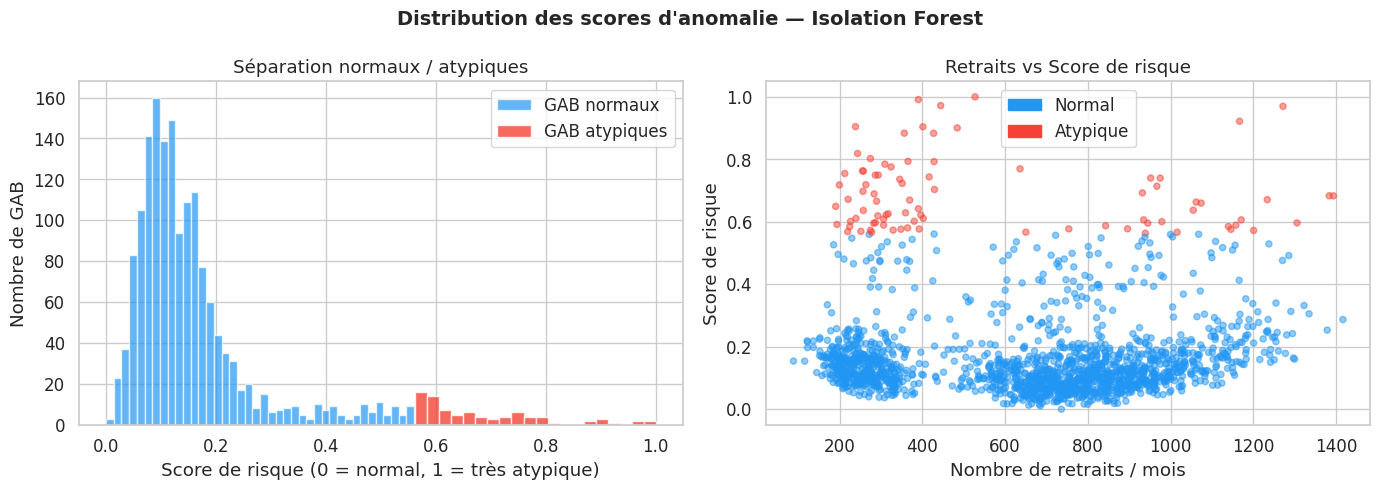

In [20]:
# ── 8.4 Visualisation du score d'anomalie ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution des scores d\'anomalie — Isolation Forest', fontsize=14, fontweight='bold')

# Histogramme des scores
ax = axes[0]
ax.hist(df[df['est_anomalie']==0]['score_risque'], bins=40,
        color=COULEUR_NORMAL, alpha=0.7, label='GAB normaux')
ax.hist(df[df['est_anomalie']==1]['score_risque'], bins=20,
        color=COULEUR_ANOMALIE, alpha=0.8, label='GAB atypiques')
ax.set_xlabel('Score de risque (0 = normal, 1 = très atypique)')
ax.set_ylabel('Nombre de GAB')
ax.set_title('Séparation normaux / atypiques')
ax.legend()

# Scatter retraits vs score risque
ax2 = axes[1]
couleurs = [COULEUR_ANOMALIE if a==1 else COULEUR_NORMAL for a in df['est_anomalie']]
ax2.scatter(df['ret_nb'], df['score_risque'], c=couleurs, alpha=0.5, s=20)
ax2.set_xlabel('Nombre de retraits / mois')
ax2.set_ylabel('Score de risque')
ax2.set_title('Retraits vs Score de risque')
patch_n = mpatches.Patch(color=COULEUR_NORMAL,   label='Normal')
patch_a = mpatches.Patch(color=COULEUR_ANOMALIE, label='Atypique')
ax2.legend(handles=[patch_n, patch_a])

plt.tight_layout()
plt.savefig('scores_anomalie.png', dpi=150, bbox_inches='tight')
plt.show()

## 8bis. 🔬 Clustering — Familles de comportements GAB

### Comparer chaque GAB à ses pairs, pas à l'ensemble du réseau

Un GAB rural et un GAB de centre commercial ne sont pas "normaux" de la même façon.  
Le clustering regroupe les GAB par **profil similaire**, permettant une comparaison plus équitable :  
un GAB est atypique **au sein de sa famille**, pas dans l'absolu.


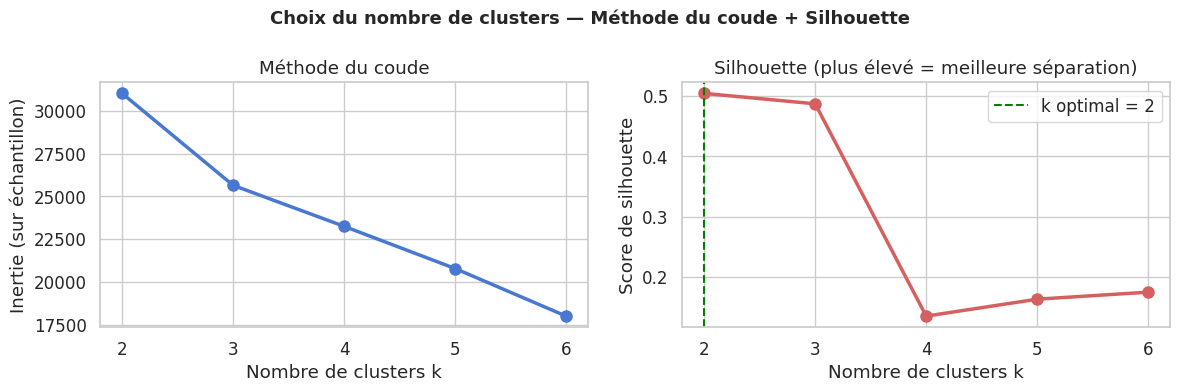

✅ k optimal : 2 clusters (silhouette = 0.505)
   (Calculé sur un échantillon de 1,680 lignes pour performance)


In [21]:
# ── 8bis.1 Clustering allégé — choix du k optimal ───────────────────────────
# Pour un dataset volumeux (>50k lignes), on travaille sur un échantillon
# représentatif pour trouver k, puis on applique le modèle sur tout le dataset.

SAMPLE_SIZE = min(5000, len(df))   # max 5 000 lignes pour la recherche de k
np.random.seed(42)
idx_sample  = np.random.choice(len(df), size=SAMPLE_SIZE, replace=False)
X_sample    = X_scaled[idx_sample]

inertias, sil_scores = [], []
K_range = range(2, 7)   # k de 2 à 6 — au-delà le gain est marginal

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=100)
    labs = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sample, labs, sample_size=min(2000,SAMPLE_SIZE)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Choix du nombre de clusters — Méthode du coude + Silhouette',
             fontsize=13, fontweight='bold')

axes[0].plot(list(K_range), inertias, 'bo-', lw=2.5, ms=8)
axes[0].set_xlabel('Nombre de clusters k')
axes[0].set_ylabel('Inertie (sur échantillon)')
axes[0].set_title('Méthode du coude')
axes[0].set_xticks(list(K_range))

axes[1].plot(list(K_range), sil_scores, 'ro-', lw=2.5, ms=8)
axes[1].set_xlabel('Nombre de clusters k')
axes[1].set_ylabel('Score de silhouette')
axes[1].set_title('Silhouette (plus élevé = meilleure séparation)')
axes[1].set_xticks(list(K_range))
k_opt = list(K_range)[sil_scores.index(max(sil_scores))]
axes[1].axvline(k_opt, color='green', ls='--', lw=1.5, label=f'k optimal = {k_opt}')
axes[1].legend()

plt.tight_layout()
plt.savefig('clustering_choix_k.png', dpi=150, bbox_inches='tight')
plt.show()

K_FINAL = k_opt
print(f'✅ k optimal : {K_FINAL} clusters (silhouette = {max(sil_scores):.3f})')
print(f'   (Calculé sur un échantillon de {SAMPLE_SIZE:,} lignes pour performance)')


In [22]:
# ── 8bis.2 KMeans final — nommage métier riche + profil radar ───────────────
# Features dédiées au clustering (comportementales, pas les features du modèle IF)
FEAT_CLUST = [
    'intensite_retrait_ajustee',
    'taux_capture_pct',
    'ret_pct_nuit',
    'ret_pct_weekend',
    'pct_reseaux_etrangers',
    'concentration_reseau',
    'cv_montant',
    'ecart_montant_vs_cp',
]
FEAT_CLUST = [f for f in FEAT_CLUST if f in df.columns]

from sklearn.preprocessing import RobustScaler
scaler_clust = RobustScaler()   # robuste aux outliers pour le clustering
X_clust = scaler_clust.fit_transform(df[FEAT_CLUST].fillna(0))

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=5, max_iter=200)
df['cluster'] = km_final.fit_predict(X_clust)

# Profil moyen par cluster
feat_profil = FEAT_CLUST + ['est_anomalie', 'ret_montant_moyen', 'ret_nb_horscos']
feat_profil = [f for f in feat_profil if f in df.columns]
profil = df.groupby('cluster')[feat_profil].mean().round(2)

# Nommage métier enrichi : on calcule un z-score intra-cluster
def nommer_cluster(cid, row, profil_df):
    zs = {}
    for f in FEAT_CLUST:
        if f in profil_df.columns:
            mu = profil_df[f].mean(); si = profil_df[f].std()+1e-9
            zs[f] = (row[f]-mu)/si
    # Priorité par signal le plus fort
    if row.get('est_anomalie',0) > 0.25:
        return f'🔴 C{cid} — Profil à risque élevé'
    if zs.get('taux_capture_pct',0) > 1.2:
        return f'🃏 C{cid} — Taux de capture élevé'
    if zs.get('ret_pct_nuit',0) > 1.2:
        return f'🌙 C{cid} — Activité nocturne intense'
    if zs.get('pct_reseaux_etrangers',0) > 1.2:
        return f'🌍 C{cid} — Fort trafic réseaux étrangers'
    if zs.get('ecart_montant_vs_cp',0) > 1.2:
        return f'💰 C{cid} — Montants élevés vs contexte local'
    if zs.get('concentration_reseau',0) > 1.2:
        return f'🔀 C{cid} — Réseau dominant unique'
    if row.get('ret_nb_horscos',0) > profil_df.get('ret_nb_horscos', pd.Series([0])).quantile(.75):
        return f'🏙️ C{cid} — Fort volume (urbain dense)'
    if row.get('intensite_retrait_ajustee',0) < profil_df.get('intensite_retrait_ajustee', pd.Series([1])).quantile(.25):
        return f'🏝️ C{cid} — Faible volume (DOM-TOM / rural)'
    return f'🟢 C{cid} — Comportement standard'

NOMS_CLUSTERS = {cid: nommer_cluster(cid, profil.iloc[cid], profil) for cid in range(K_FINAL)}
df['cluster_nom'] = df['cluster'].map(NOMS_CLUSTERS)

print('📊 Profil moyen par cluster :')
fmt_cols = [f for f in feat_profil if f in profil.columns and f != 'est_anomalie']
display(profil.rename(index=NOMS_CLUSTERS).style
    .background_gradient(cmap='YlOrRd', subset=fmt_cols)
    .format('{:.2f}'))

print('\n📋 Répartition et taux d\'anomalie :')
dist = df.groupby(['cluster','cluster_nom']).agg(
    nb_obs=('num_automate','count'), pct_anom=('est_anomalie','mean')
).reset_index()
dist['% Atypiques'] = (dist['pct_anom']*100).round(1)
dist.columns = ['Cluster','Nom','Nb obs.','_','% Atypiques']
print(dist[['Cluster','Nom','Nb obs.','% Atypiques']].to_string(index=False))

# ── Radar comparatif des profils de clusters ──────────────────────────────────
feat_radar = ['taux_capture_pct','ret_pct_nuit','ret_pct_weekend',
              'pct_reseaux_etrangers','concentration_reseau','ecart_montant_vs_cp']
feat_radar = [f for f in feat_radar if f in profil.columns]
lbl_radar  = ['Capture','Nuit','Weekend','Étranger','Conc. réseau','Montant/CP'][:len(feat_radar)]

ref_min = df[feat_radar].quantile(0.05)
ref_max = df[feat_radar].quantile(0.95)
profil_norm = (profil[feat_radar] - ref_min) / (ref_max - ref_min + 1e-9)

fig_radar = go.Figure()
for cid in range(K_FINAL):
    vals = profil_norm.iloc[cid].tolist()
    fig_radar.add_trace(go.Scatterpolar(
        r=vals+[vals[0]], theta=lbl_radar+[lbl_radar[0]],
        fill='toself', name=NOMS_CLUSTERS[cid],
        line_color=PALETTE_CLUSTERS[cid % len(PALETTE_CLUSTERS)],
        fillcolor=PALETTE_CLUSTERS[cid % len(PALETTE_CLUSTERS)],
        opacity=0.30,
    ))

fig_radar.update_layout(
    polar={'radialaxis':{'visible':True,'range':[0,1.3]}},
    title='Radar — Profil normalisé de chaque cluster (0=min réseau, 1=max réseau)',
    height=500, legend={'font':{'size':10}},
)
fig_radar.show()
print('💡 Le radar permet de voir d\'un coup d\'œil quelle dimension définit chaque cluster.')


📊 Profil moyen par cluster :


,intensite_retrait_ajustee,taux_capture_pct,ret_pct_nuit,ret_pct_weekend,pct_reseaux_etrangers,concentration_reseau,cv_montant,ecart_montant_vs_cp,est_anomalie,ret_montant_moyen,ret_nb_horscos
cluster,,,,,,,,,,,
🏙️ C0 — Fort volume (urbain dense),23.32,0.78,11.00,22.19,1.63,0.38,0.43,-0.43,0.02,162.54,606.15
🔴 C1 — Profil à risque élevé,24.41,0.77,11.27,23.61,30.97,0.27,1.01,12.80,0.96,177.14,406.95



📋 Répartition et taux d'anomalie :
 Cluster                                Nom  Nb obs.  % Atypiques
       0 🏙️ C0 — Fort volume (urbain dense)     1625          1.9
       1       🔴 C1 — Profil à risque élevé       55         96.4


💡 Le radar permet de voir d'un coup d'œil quelle dimension définit chaque cluster.


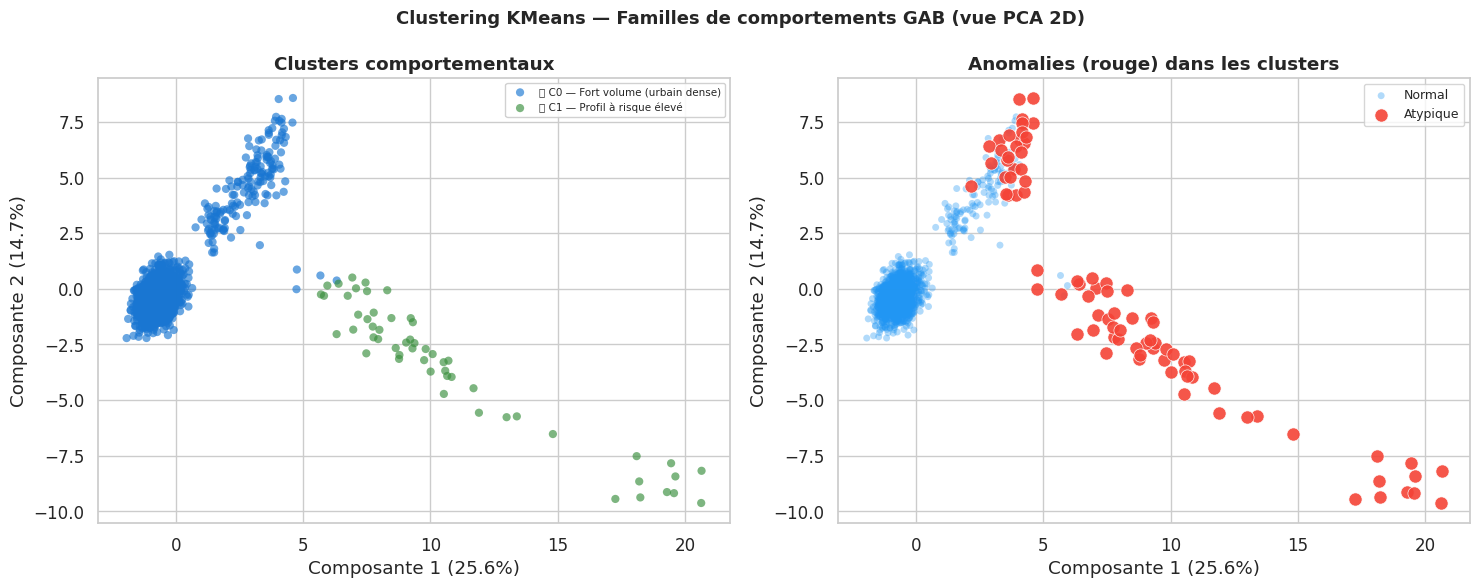

💡 Les 2 composantes PCA expliquent 40.3% de la variance totale.


In [23]:
# ── 8bis.3 Visualisation des clusters en 2D (PCA) ────────────────────────────
pca_clust = PCA(n_components=2, random_state=42)
Xp = pca_clust.fit_transform(X_scaled)
df['_pca1'], df['_pca2'] = Xp[:, 0], Xp[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Clustering KMeans — Familles de comportements GAB (vue PCA 2D)',
             fontsize=13, fontweight='bold')

# Gauche : clusters colorés
ax = axes[0]
for cid in sorted(df['cluster'].unique()):
    mask = df['cluster'] == cid
    color = PALETTE_CLUSTERS[cid % len(PALETTE_CLUSTERS)]
    ax.scatter(df.loc[mask,'_pca1'], df.loc[mask,'_pca2'],
               c=color, label=NOMS_CLUSTERS[cid],
               alpha=0.65, s=35, edgecolors='none')
ax.set_title('Clusters comportementaux', fontweight='bold')
ax.legend(loc='best', fontsize=7.5, framealpha=0.9)
ax.set_xlabel(f'Composante 1 ({pca_clust.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'Composante 2 ({pca_clust.explained_variance_ratio_[1]*100:.1f}%)')

# Droite : anomalies dans les clusters
ax2 = axes[1]
for label, mask, color, size, alpha in [
    ('Normal',   df['est_anomalie']==0, COULEUR_NORMAL,   25, 0.35),
    ('Atypique', df['est_anomalie']==1, COULEUR_ANOMALIE, 90, 0.90),
]:
    ax2.scatter(df.loc[mask,'_pca1'], df.loc[mask,'_pca2'],
                c=color, label=label, s=size, alpha=alpha,
                edgecolors='white' if size>40 else 'none', lw=0.5)
ax2.set_title('Anomalies (rouge) dans les clusters', fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_xlabel(f'Composante 1 ({pca_clust.explained_variance_ratio_[0]*100:.1f}%)')
ax2.set_ylabel(f'Composante 2 ({pca_clust.explained_variance_ratio_[1]*100:.1f}%)')

plt.tight_layout()
plt.savefig('clustering_pca.png', dpi=150, bbox_inches='tight')
plt.show()

exp_var = (pca_clust.explained_variance_ratio_[:2].sum()*100)
print(f'💡 Les 2 composantes PCA expliquent {exp_var:.1f}% de la variance totale.')


## 9. 🔎 Explication des Anomalies Détectées

### Pourquoi ces GAB sont-ils atypiques ?

C'est **la partie la plus importante** pour convaincre les experts métier.  
Chaque anomalie doit être **expliquée en langage métier**.

In [24]:
# ── 9.1 Top 10 GAB atypiques — table enrichie avec raison et contexte ───────
cols_top = ['num_automate','score_risque','ret_nb_horscos','ret_montant_moyen',
            'taux_capture_pct','ret_pct_nuit','ret_pct_weekend',
            'cluster_nom','reseau_dominant','type_gab_e_i']
if 'raison_principale' in df.columns:
    cols_top.append('raison_principale')
cols_top = [c for c in cols_top if c in df.columns]

top_anom = df[df['est_anomalie']==1].nlargest(10,'score_risque')[cols_top].reset_index(drop=True)
top_anom.index += 1

rename = {
    'num_automate':'Automate','score_risque':'Score',
    'ret_nb_horscos':'Retraits hors-COS','ret_montant_moyen':'Montant moy (€)',
    'taux_capture_pct':'Capture (%)','ret_pct_nuit':'% Nuit','ret_pct_weekend':'% Weekend',
    'cluster_nom':'Cluster','reseau_dominant':'Réseau dom.','type_gab_e_i':'Type',
    'raison_principale':'⚠️ Raison principale',
}
top_anom = top_anom.rename(columns=rename)

fmt = {'Score':'{:.3f}','Capture (%)':'{:.2f}','Montant moy (€)':'{:.0f}',
       '% Nuit':'{:.1f}','% Weekend':'{:.1f}'}
fmt = {k:v for k,v in fmt.items() if k in top_anom.columns}

style = top_anom.style.format(fmt)
for gc in ['Score','Capture (%)']:
    if gc in top_anom.columns: style = style.background_gradient(subset=[gc], cmap='Reds')

print('🚨 TOP 10 des GAB les plus atypiques — raison métier incluse :')
display(style)


🚨 TOP 10 des GAB les plus atypiques — raison métier incluse :


,Automate,Score,Retraits hors-COS,Montant moy (€),Capture (%),% Nuit,% Weekend,Cluster,Réseau dom.,Type
1,GAB_0138,1.000,480,144,0.93,9.8,19.7,🔴 C1 — Profil à risque élevé,cb,Interne
2,GAB_0122,0.991,300,152,0.28,14.0,22.7,🔴 C1 — Profil à risque élevé,jcb,Externe
3,GAB_0122,0.972,409,116,0.95,9.6,24.4,🔴 C1 — Profil à risque élevé,jcb,Externe
4,GAB_0134,0.970,1192,167,1.55,12.2,25.7,🔴 C1 — Profil à risque élevé,cb,Externe
5,GAB_0134,0.922,1131,189,0.61,11.8,22.1,🔴 C1 — Profil à risque élevé,jcb,Externe
6,GAB_0130,0.905,225,188,0.49,8.3,19.4,🔴 C1 — Profil à risque élevé,cb,Externe
7,GAB_0138,0.904,346,164,0.70,17.3,21.8,🔴 C1 — Profil à risque élevé,jcb,Externe
8,GAB_0126,0.901,411,181,0.34,8.4,29.7,🔴 C1 — Profil à risque élevé,jcb,Externe
9,GAB_0130,0.884,302,174,0.61,11.7,18.9,🔴 C1 — Profil à risque élevé,jcb,Interne
10,GAB_0126,0.883,366,170,1.31,14.1,21.9,🔴 C1 — Profil à risque élevé,jcb,Interne


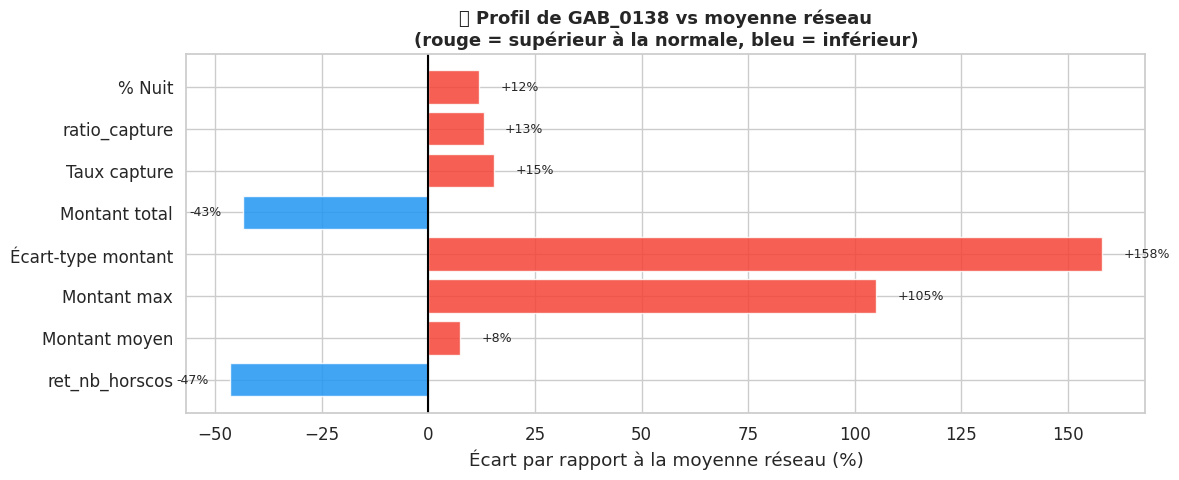


📋 Interprétation métier de GAB_0138 :
   → Taux de capture : 0.9%  (réseau : 0.7%)
   → Montant moyen   : 144€  (réseau : 163€)
   → Activité nocturne : 9.8%  (réseau : 10.8%)


In [25]:
# ── 9.2 Profil d'un GAB atypique vs le réseau ─────────────────────────────────
# Sélection du GAB le plus atypique
gab_anomalie = df[df['est_anomalie']==1].nlargest(1, 'score_risque').iloc[0]
gab_id = gab_anomalie['num_automate']

# Moyennes réseau (normaux)
moyennes_normaux = df[df['est_anomalie']==0][FEATURES_MODELE[:8]].mean()
valeurs_anomalie = df[df['num_automate']==gab_id][FEATURES_MODELE[:8]].mean()

# Calcul des écarts en % par rapport à la moyenne
ecarts = ((valeurs_anomalie - moyennes_normaux) / moyennes_normaux * 100).clip(-200, 500)

labels_fr = {
    'ret_nb'             : 'Nb retraits',
    'ret_montant_moyen'  : 'Montant moyen',
    'ret_montant_max'    : 'Montant max',
    'ret_montant_stddev' : 'Écart-type montant',
    'ret_montant_total'  : 'Montant total',
    'taux_capture_pct'   : 'Taux capture',
    'ret_pct_nuit'       : '% Nuit',
    'ret_pct_weekend'    : '% Weekend',
}

fig, ax = plt.subplots(figsize=(12, 5))
couleurs_barres = [COULEUR_ANOMALIE if v > 0 else COULEUR_NORMAL for v in ecarts.values]
bars = ax.barh([labels_fr.get(c, c) for c in ecarts.index], ecarts.values,
               color=couleurs_barres, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=1.5)
ax.set_xlabel('Écart par rapport à la moyenne réseau (%)')
ax.set_title(f'🔍 Profil de {gab_id} vs moyenne réseau\n(rouge = supérieur à la normale, bleu = inférieur)',
             fontsize=13, fontweight='bold')

# Annotations valeur absolue
for bar, val in zip(bars, ecarts.values):
    x = bar.get_width()
    ax.text(x + (5 if x >= 0 else -5), bar.get_y() + bar.get_height()/2,
            f'{val:+.0f}%', va='center', ha='left' if x >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('profil_anomalie.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📋 Interprétation métier de {gab_id} :')
print(f'   → Taux de capture : {gab_anomalie["taux_capture_pct"]:.1f}%  (réseau : {moyennes_normaux["taux_capture_pct"]:.1f}%)')
print(f'   → Montant moyen   : {gab_anomalie["ret_montant_moyen"]:.0f}€  (réseau : {moyennes_normaux["ret_montant_moyen"]:.0f}€)')
print(f'   → Activité nocturne : {gab_anomalie["ret_pct_nuit"]:.1f}%  (réseau : {moyennes_normaux["ret_pct_nuit"]:.1f}%)')

In [26]:
# ── 9.3 Radar chart : comparaison GAB atypique vs réseau ──────────────────────
categories = ['Nb retraits', 'Montant moyen', 'Taux capture',
              '% Nuit', '% Weekend', 'Ratio capture']
cols_radar  = ['ret_nb','ret_montant_moyen','taux_capture_pct',
               'ret_pct_nuit','ret_pct_weekend','ratio_capture']

# Normalisation min-max pour le radar
def normaliser_radar(valeurs, ref_min, ref_max):
    return [(v - mn) / (mx - mn + 1e-9) for v, mn, mx in zip(valeurs, ref_min, ref_max)]

ref_min = df[cols_radar].quantile(0.05).values
ref_max = df[cols_radar].quantile(0.95).values

vals_anomalie = normaliser_radar(df[df['num_automate']==gab_id][cols_radar].mean().values, ref_min, ref_max)
vals_normal   = normaliser_radar(df[df['est_anomalie']==0][cols_radar].mean().values, ref_min, ref_max)

fig_radar = go.Figure()
for vals, nom, couleur in [
    (vals_anomalie, f'{gab_id} (Atypique)', COULEUR_ANOMALIE),
    (vals_normal,   'Moyenne réseau (Normal)', COULEUR_NORMAL),
]:
    fig_radar.add_trace(go.Scatterpolar(
        r=vals + [vals[0]],
        theta=categories + [categories[0]],
        fill='toself',
        name=nom,
        line_color=couleur,
        fillcolor=couleur,
        opacity=0.35
    ))

fig_radar.update_layout(
    polar={'radialaxis': {'visible': True, 'range': [0, 1]}},
    title=f'Radar — {gab_id} vs Moyenne réseau',
    height=500
)
fig_radar.show()
print('💡 Le GAB atypique dépasse significativement la zone normale sur plusieurs axes simultanément.')

💡 Le GAB atypique dépasse significativement la zone normale sur plusieurs axes simultanément.


In [27]:
# ── 9.4 Carte des anomalies détectées — avec raison et cluster ─────────────
cp_col = 'code_postale_emplacement' if 'code_postale_emplacement' in df.columns else 'code_postal'

agg2 = {
    'longitude':     ('longitude',           'first'),
    'latitude':      ('latitude',            'first'),
    'score_risque':  ('score_risque',        'mean'),
    'est_anomalie':  ('est_anomalie',        'max'),
    'ret_nb_moy':    ('ret_nb_horscos',      'mean'),
    'taux_cap':      ('taux_capture_pct',    'mean'),
    'cluster_nom':   ('cluster_nom',         'first'),
    'cp':            (cp_col,                'first'),
    'contexte':      ('contexte_geo',        'first'),
}
if 'raison_principale' in df.columns:
    agg2['raison'] = ('raison_principale','first')

df_geo2 = df.groupby('num_automate').agg(**agg2).reset_index()
df_geo2['statut'] = df_geo2['est_anomalie'].map({0:'✅ Normal','1':'🔴 Atypique',1:'🔴 Atypique'})

# Taille proportionnelle au score de risque pour les atypiques
df_geo2['size_m'] = np.where(
    df_geo2['est_anomalie']==1,
    df_geo2['score_risque']*25 + 8,
    5
)

hover2 = {'cp':True,'contexte':True,'taux_cap':':.2f','ret_nb_moy':':.0f',
           'score_risque':':.3f','cluster_nom':True,'statut':False,
           'latitude':False,'longitude':False,'size_m':False}
if 'raison' in df_geo2.columns: hover2['raison'] = True

fig_anom = px.scatter_mapbox(
    df_geo2, lat='latitude', lon='longitude',
    color='statut',
    color_discrete_map={'✅ Normal':'#90CAF9','🔴 Atypique':'#C62828'},
    size='size_m', size_max=30,
    hover_name='num_automate', hover_data=hover2,
    zoom=3, center={'lat':25,'lon':-10},
    mapbox_style='carto-positron',
    title='🗺️ Anomalies géolocalisées — Taille = score de risque · Hover = raison',
    height=580,
)
fig_anom.update_layout(margin={'r':0,'t':50,'l':0,'b':0})
fig_anom.show()
print('💡 Survolez un point rouge pour voir la raison métier de l\'anomalie.')


💡 Survolez un point rouge pour voir la raison métier de l'anomalie.


## 9bis. 🏷️ Raison d'atypisme & Vue consolidée annuelle

### Un GAB ne doit apparaître qu'une seule fois

L'analyse mensuelle peut faire apparaître le même GAB plusieurs fois.  
Ici on consolide : **1 ligne par GAB**, avec le nombre de mois atypiques, la raison principale, et le cluster associé.


In [29]:
# ── 9bis.1 Raisons d'atypisme — variées, contextuelles, métier ──────────────
cp_col = 'code_postale_emplacement' if 'code_postale_emplacement' in df.columns else 'code_postal'

# Références réseau (normaux uniquement)
normaux = df[df['est_anomalie']==0]
moy_ref = {
    'taux_capture_pct':      normaux['taux_capture_pct'].mean(),
    'ret_pct_nuit':          normaux['ret_pct_nuit'].mean(),
    'ret_pct_weekend':       normaux['ret_pct_weekend'].mean(),
    'ret_montant_moyen':     normaux['ret_montant_moyen'].mean(),
    'ret_nb_horscos':        normaux['ret_nb_horscos'].mean(),
    'pct_reseaux_etrangers': normaux['pct_reseaux_etrangers'].mean(),
    'concentration_reseau':  normaux['concentration_reseau'].mean(),
    'cv_montant':            normaux['cv_montant'].mean(),
}

def generer_raison_metier(row, moy, df_ref):
    """
    Génère une raison métier variée et contextuelle.
    Priorité SQL → raison Python enrichie.
    """
    # 1. Priorité raison SQL si disponible et informative
    if 'raison_atypisme' in row.index:
        r = str(row.get('raison_atypisme',''))
        if r not in ('nan','Combinaison de signaux faibles','—',''):
            return r, r

    signaux = []
    val = lambda c: row.get(c, np.nan) if hasattr(row,'get') else row[c] if c in row.index else np.nan

    # ── Règles métier enrichies et variées ────────────────────────────────────
    tc = val('taux_capture_pct')
    if not np.isnan(tc) and moy.get('taux_capture_pct',0) > 0:
        if (tc - moy['taux_capture_pct']) / moy['taux_capture_pct'] > 0.6:
            signaux.append(f'Taux de capture anormalement élevé ({tc:.1f}% vs moy. réseau {moy["taux_capture_pct"]:.1f}%)')

    pn = val('ret_pct_nuit')
    if not np.isnan(pn) and moy.get('ret_pct_nuit',0) > 0:
        if (pn - moy['ret_pct_nuit']) / moy['ret_pct_nuit'] > 0.6:
            signaux.append(f'Activité nocturne excessive ({pn:.1f}% vs moy. {moy["ret_pct_nuit"]:.1f}%)')

    pe = val('pct_reseaux_etrangers')
    if not np.isnan(pe) and moy.get('pct_reseaux_etrangers',0) > 0:
        if (pe - moy['pct_reseaux_etrangers']) / (moy['pct_reseaux_etrangers']+0.1) > 1.5:
            signaux.append(f'Concentration anormale sur réseaux étrangers ({pe:.1f}% du total)')

    conc = val('concentration_reseau')
    if not np.isnan(conc) and moy.get('concentration_reseau',0) > 0:
        if conc > 0.85:
            dom = val('reseau_dominant') if 'reseau_dominant' in row.index else '?'
            signaux.append(f'Un seul réseau ({dom}) représente {conc*100:.0f}% de l\'activité')

    mm = val('ret_montant_moyen')
    ecp = val('ecart_montant_vs_cp')
    if not np.isnan(mm) and not np.isnan(ecp):
        if ecp > 60:
            signaux.append(f'Montant moyen ({mm:.0f}€) très élevé vs GAB du même territoire (+{ecp:.0f}%)')
        elif mm > moy.get('ret_montant_moyen',0)*1.5:
            signaux.append(f'Montant moyen de retrait élevé ({mm:.0f}€ vs moy. réseau {moy["ret_montant_moyen"]:.0f}€)')

    rh = val('ret_nb_horscos')
    if not np.isnan(rh) and moy.get('ret_nb_horscos',0) > 0:
        ratio = (rh - moy['ret_nb_horscos']) / moy['ret_nb_horscos']
        if ratio > 0.6:
            signaux.append(f'Volume de retraits élevé ({rh:.0f} vs moy. {moy["ret_nb_horscos"]:.0f})')
        elif ratio < -0.6:
            signaux.append(f'Volume anormalement bas — panne possible ? ({rh:.0f} vs moy. {moy["ret_nb_horscos"]:.0f})')

    pw = val('ret_pct_weekend')
    if not np.isnan(pw) and moy.get('ret_pct_weekend',0) > 0:
        if (pw - moy['ret_pct_weekend']) / moy['ret_pct_weekend'] > 0.5:
            signaux.append(f'Activité weekend anormalement élevée ({pw:.1f}% vs {moy["ret_pct_weekend"]:.1f}%)')

    cvm = val('cv_montant')
    if not np.isnan(cvm) and moy.get('cv_montant',0) > 0:
        if cvm > moy['cv_montant'] * 1.8:
            signaux.append(f'Grande variabilité des montants (coefficient de variation {cvm:.2f})')

    if not signaux:
        signaux.append('Combinaison de signaux faibles sur plusieurs métriques')

    return signaux[0], ' | '.join(signaux[:3])

res = df[df['est_anomalie']==1].apply(
    lambda r: generer_raison_metier(r, moy_ref, normaux), axis=1)
df.loc[df['est_anomalie']==1,'raison_principale'] = [r[0] for r in res]
df.loc[df['est_anomalie']==1,'detail_atypisme']   = [r[1] for r in res]

# Affichage de la diversité des raisons
print('📋 Distribution des raisons d\'atypisme (variété métier) :')
raisons_dist = df[df['est_anomalie']==1]['raison_principale'].str.split(' \(').str[0].value_counts()
for raison, cnt in raisons_dist.items():
    barre = '█' * cnt
    print(f'   {barre:<20} {cnt:3d}  {raison[:65]}')

# ── 9bis.2 Vue annuelle — 1 ligne par GAB ─────────────────────────────────────
agg_annuel = {
    'ret_nb_horscos':        ('ret_nb_horscos',       'sum'),
    'ret_montant_moyen':     ('ret_montant_moyen',    'mean'),
    'taux_capture_moyen':    ('taux_capture_pct',     'mean'),
    'pct_nuit_moyen':        ('ret_pct_nuit',         'mean'),
    'pct_wk_moyen':          ('ret_pct_weekend',      'mean'),
    'pct_etr_moyen':         ('pct_reseaux_etrangers','mean'),
    'nb_mois_atypiques':     ('flag_atypique',        'sum'),
    'nb_mois_actifs':        ('flag_atypique',        'count'),
    'est_anomalie':          ('est_anomalie',         'max'),
    'score_risque':          ('score_risque',         'max'),
    'cluster_nom':           ('cluster_nom',          'first'),
    'type_gab_e_i':          ('type_gab_e_i',        'first'),
    'cp':                    (cp_col,                 'first'),
    'contexte_geo':          ('contexte_geo',         'first'),
    'longitude':             ('longitude',            'first'),
    'latitude':              ('latitude',             'first'),
    'is_dom_tom':            ('is_dom_tom',           'max'),
    'reseau_dominant':       ('reseau_dominant',      'first'),
}

df_annuel = df.groupby('num_automate').agg(**agg_annuel).reset_index()
df_annuel['pct_mois_atypiques'] = (
    df_annuel['nb_mois_atypiques'] / df_annuel['nb_mois_actifs'] * 100).round(1)
df_annuel['categorie_risque'] = pd.cut(
    df_annuel['nb_mois_atypiques'],
    bins=[-1,0,2,5,100],
    labels=['🟢 Normal','🟡 Modéré (1-2 mois)','🟠 Élevé (3-5 mois)','🔴 Critique (6+ mois)']
)

raison_gab = (df[df['est_anomalie']==1].groupby('num_automate')['raison_principale']
              .agg(lambda x: x.value_counts().index[0] if len(x)>0 else 'N/A'))
df_annuel['raison_principale'] = df_annuel['num_automate'].map(raison_gab).fillna('—')

n_atyp = (df_annuel['nb_mois_atypiques']>0).sum()
print(f'\n📋 Vue annuelle : {len(df_annuel)} GAB uniques')
print(f'   🔴 Avec au moins 1 mois atypique : {n_atyp}')
print(df_annuel['categorie_risque'].value_counts().sort_index().to_string())


📋 Distribution des raisons d'atypisme (variété métier) :
   █████████████████████████████████████████████  45  Concentration anormale sur réseaux étrangers
   ██████████████████████████████  30  Taux de capture anormalement élevé
   ████████               8  Activité nocturne excessive
   █                      1  Montant moyen

📋 Vue annuelle : 140 GAB uniques
   🔴 Avec au moins 1 mois atypique : 18
categorie_risque
🟢 Normal                122
🟡 Modéré (1-2 mois)       0
🟠 Élevé (3-5 mois)        0
🔴 Critique (6+ mois)     18


In [30]:
# ── 9bis.3 Table de synthèse annuelle — 1 GAB = 1 ligne ────────────────────
cols_show = ['num_automate','cp','contexte_geo','nb_mois_atypiques','pct_mois_atypiques',
             'categorie_risque','score_risque','cluster_nom','raison_principale',
             'taux_capture_moyen','pct_nuit_moyen','pct_etr_moyen','reseau_dominant']
cols_show = [c for c in cols_show if c in df_annuel.columns]

top_annuel = (df_annuel[df_annuel['nb_mois_atypiques']>0]
              .sort_values(['nb_mois_atypiques','score_risque'], ascending=[False,False])
              [cols_show].reset_index(drop=True))
top_annuel.index += 1

fmt = {c:'{:.1f}' for c in ['pct_mois_atypiques','taux_capture_moyen',
                              'pct_nuit_moyen','pct_etr_moyen','score_risque']
       if c in top_annuel.columns}

style = top_annuel.head(20).style.format(fmt)
for gc in ['nb_mois_atypiques','score_risque']:
    if gc in top_annuel.columns:
        style = style.background_gradient(subset=[gc], cmap='YlOrRd' if 'mois' in gc else 'Reds')

print(f'🏧 {len(top_annuel)} GAB atypiques — vue annuelle consolidée :')
display(style)


🏧 18 GAB atypiques — vue annuelle consolidée :


,num_automate,cp,contexte_geo,nb_mois_atypiques,pct_mois_atypiques,categorie_risque,score_risque,cluster_nom,raison_principale,taux_capture_moyen,pct_nuit_moyen,pct_etr_moyen,reseau_dominant
1,GAB_0138,97100,Guadeloupe,12,100.0,🔴 Critique (6+ mois),1.0,🔴 C1 — Profil à risque élevé,Concentration anormale sur réseaux étrangers (34.0% du total),0.8,12.1,29.3,cb
2,GAB_0122,97300,Guyane,12,100.0,🔴 Critique (6+ mois),1.0,🔴 C1 — Profil à risque élevé,Taux de capture anormalement élevé (1.3% vs moy. réseau 0.7%),0.8,12.5,29.1,cb
3,GAB_0134,69001,Métropole,12,100.0,🔴 Critique (6+ mois),1.0,🔴 C1 — Profil à risque élevé,Concentration anormale sur réseaux étrangers (35.4% du total),0.9,11.5,28.9,cb
4,GAB_0130,97150,Saint-Martin,12,100.0,🔴 Critique (6+ mois),0.9,🔴 C1 — Profil à risque élevé,Concentration anormale sur réseaux étrangers (23.5% du total),0.7,10.7,30.8,cb
5,GAB_0126,97300,Guyane,12,100.0,🔴 Critique (6+ mois),0.9,🔴 C1 — Profil à risque élevé,Concentration anormale sur réseaux étrangers (26.9% du total),0.9,11.3,28.7,cb
6,GAB_0124,75001,Métropole,12,100.0,🔴 Critique (6+ mois),0.7,🏙️ C0 — Fort volume (urbain dense),Taux de capture anormalement élevé (8.3% vs moy. réseau 0.7%),10.1,11.5,1.9,cb
7,GAB_0128,75001,Métropole,12,100.0,🔴 Critique (6+ mois),0.7,🏙️ C0 — Fort volume (urbain dense),Taux de capture anormalement élevé (11.7% vs moy. réseau 0.7%),7.8,12.9,1.7,cb
8,GAB_0136,97400,Réunion,12,100.0,🔴 Critique (6+ mois),0.6,🏙️ C0 — Fort volume (urbain dense),Taux de capture anormalement élevé (13.6% vs moy. réseau 0.7%),9.3,10.8,1.9,cb
9,GAB_0125,97300,Guyane,12,100.0,🔴 Critique (6+ mois),0.6,🏙️ C0 — Fort volume (urbain dense),Activité nocturne excessive (56.3% vs moy. 10.8%),0.7,45.4,1.9,cb
10,GAB_0129,13001,Métropole,12,100.0,🔴 Critique (6+ mois),0.6,🏙️ C0 — Fort volume (urbain dense),Activité nocturne excessive (54.6% vs moy. 10.8%),0.7,41.8,1.5,cb


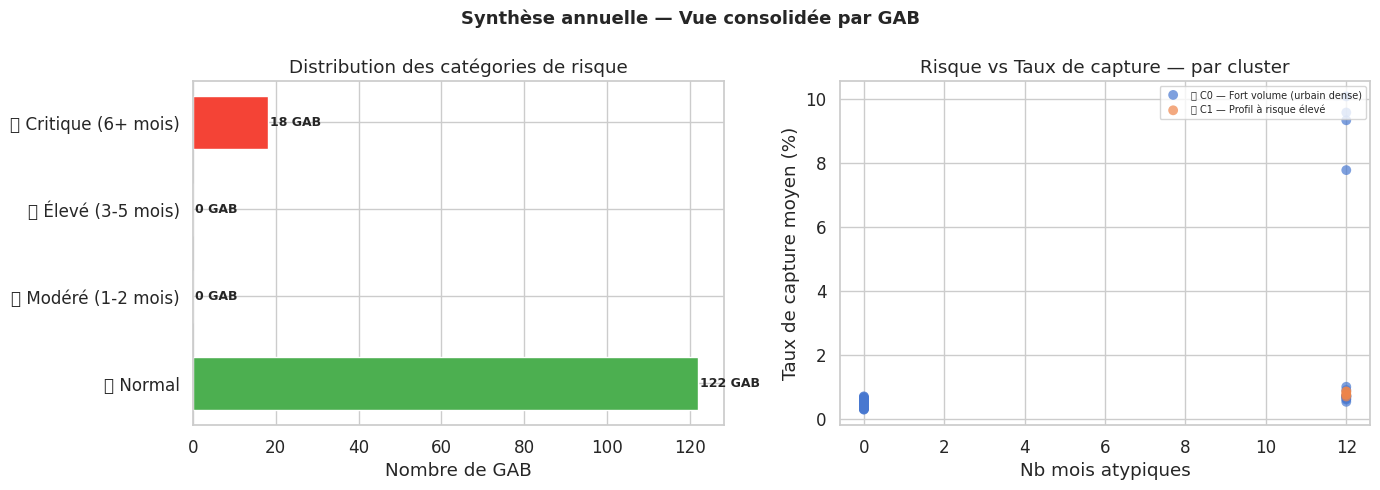

In [31]:
# ── 9bis.4 Graphique synthèse annuelle ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Synthèse annuelle — Vue consolidée par GAB', fontsize=13, fontweight='bold')

# Gauche : distribution des catégories de risque
ax1 = axes[0]
cat_counts = df_annuel['categorie_risque'].value_counts().sort_index()
bar_colors  = ['#4CAF50', '#FFC107', '#FF9800', '#F44336'][:len(cat_counts)]
bars = ax1.barh(cat_counts.index.astype(str), cat_counts.values,
                color=bar_colors, edgecolor='white', height=0.6)
ax1.set_title('Distribution des catégories de risque')
ax1.set_xlabel('Nombre de GAB')
for bar, val in zip(bars, cat_counts.values):
    ax1.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
             f'{val} GAB', va='center', fontsize=9, fontweight='bold')

# Droite : scatter nb_mois_atypiques vs taux_capture coloré par cluster
ax2 = axes[1]
for cid in sorted(df_annuel['cluster_nom'].unique()):
    mask = df_annuel['cluster_nom'] == cid
    cid_num = df_annuel.loc[mask,'cluster_nom'].index[0] % len(PALETTE_CLUSTERS)
    ax2.scatter(df_annuel.loc[mask,'nb_mois_atypiques'],
                df_annuel.loc[mask,'taux_capture_moyen'],
                label=cid, alpha=0.7, s=50, edgecolors='none')
ax2.set_xlabel('Nb mois atypiques')
ax2.set_ylabel('Taux de capture moyen (%)')
ax2.set_title('Risque vs Taux de capture — par cluster')
ax2.legend(fontsize=7, loc='upper right', framealpha=0.8)

plt.tight_layout()
plt.savefig('synthese_annuelle.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. ✅ Validation du Modèle

### Comment évaluer un modèle sans étiquettes ?

Sans vérité terrain, nous utilisons 3 méthodes de validation alternatives :

1. **Validation statistique** : les anomalies détectées sont-elles vraiment aux extrêmes des distributions ?
2. **Analyse des cas extrêmes** : les GAB avec z-score > 3 sont-ils bien détectés ?
3. **Plausibilité métier** : les explications correspondent-elles à des situations connues ?

In [32]:
# ── 10.1 Validation statistique ───────────────────────────────────────────────
print('📊 Comparaison statistique : Normaux vs Atypiques')
print('=' * 65)

stats_comp = df.groupby('est_anomalie')[[
    'ret_nb','ret_montant_moyen','taux_capture_pct','ret_pct_nuit'
]].mean().round(2)

stats_comp.index = ['🟢 Normaux', '🔴 Atypiques']
stats_comp.columns = ['Nb retraits', 'Montant moyen (€)', 'Taux capture (%)', '% Nuit']

print(stats_comp.to_string())
print()

# Ratios
ratios = (stats_comp.loc['🔴 Atypiques'] / stats_comp.loc['🟢 Normaux']).round(2)
print('📈 Ratios Atypiques / Normaux :')
for col, ratio in ratios.items():
    indicateur = '🔴 Anormal' if ratio > 1.5 or ratio < 0.5 else '🟡 Notable' if ratio > 1.2 else '🟢 Proche'
    print(f'   {indicateur}  {col} : ×{ratio}')

📊 Comparaison statistique : Normaux vs Atypiques
             Nb retraits  Montant moyen (€)  Taux capture (%)  % Nuit
🟢 Normaux         659.24             162.51              0.66   10.80
🔴 Atypiques       558.65             172.70              2.98   14.98

📈 Ratios Atypiques / Normaux :
   🟢 Proche  Nb retraits : ×0.85
   🟢 Proche  Montant moyen (€) : ×1.06
   🔴 Anormal  Taux capture (%) : ×4.52
   🟡 Notable  % Nuit : ×1.39


In [33]:
# ── 10.2 Validation par z-scores (règle des 3σ) ───────────────────────────────
cols_zscore = ['ret_nb','ret_montant_moyen','taux_capture_pct','ret_pct_nuit']

for col in cols_zscore:
    mu  = df[col].mean()
    sig = df[col].std()
    df[f'zscore_{col}'] = (df[col] - mu) / (sig + 1e-9)

df['nb_zscore_extreme'] = sum(
    (df[f'zscore_{c}'].abs() > 3).astype(int) for c in cols_zscore
)

# Taux de détection croisée
detectes_zscore    = df[df['nb_zscore_extreme'] >= 1]['est_anomalie'].mean()
non_detectes_model = df[(df['est_anomalie']==1) & (df['nb_zscore_extreme']==0)].shape[0]

print(f'🔬 Validation croisée :')
print(f'   → {detectes_zscore*100:.1f}% des cas extrêmes (z>3) sont classés atypiques par le modèle')
print(f'   → {non_detectes_model} anomalies détectées par le modèle MAIS non visibles par z-score simple')
print(f'     (→ ce sont les anomalies subtiles, invisibles à l\'œil nu 🎯)')

🔬 Validation croisée :
   → 19.0% des cas extrêmes (z>3) sont classés atypiques par le modèle
   → 56 anomalies détectées par le modèle MAIS non visibles par z-score simple
     (→ ce sont les anomalies subtiles, invisibles à l'œil nu 🎯)


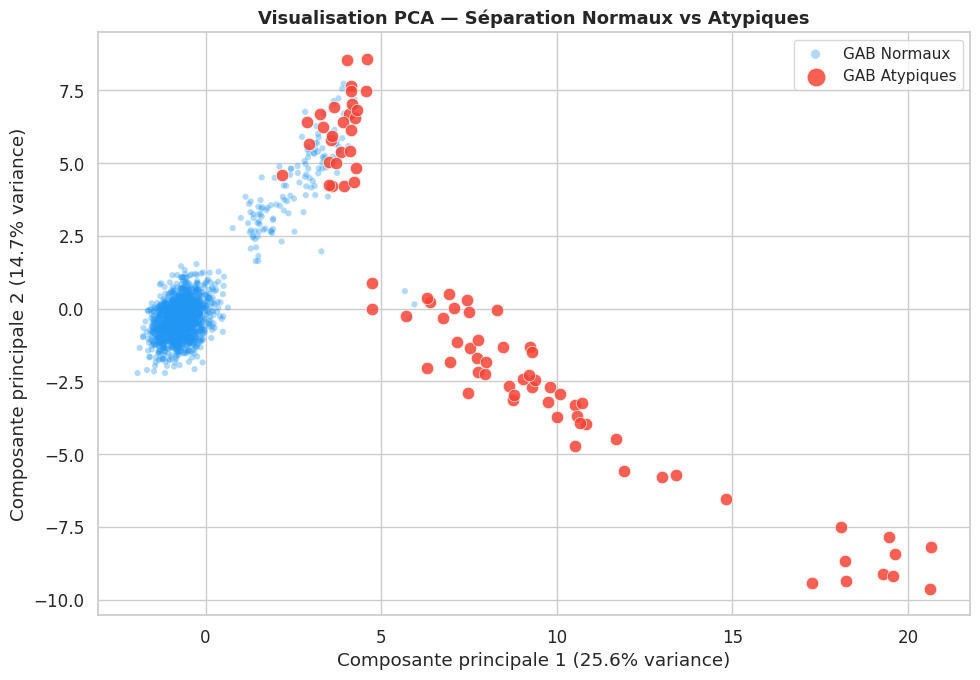

💡 Les points rouges (atypiques) se situent bien aux marges du nuage principal → validation visuelle.


In [34]:
# ── 10.3 Réduction dimensionnelle PCA pour visualisation ──────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))

for label, mask, couleur, taille, alpha in [
    ('GAB Normaux',   df['est_anomalie']==0, COULEUR_NORMAL,   20, 0.35),
    ('GAB Atypiques', df['est_anomalie']==1, COULEUR_ANOMALIE, 80, 0.85),
]:
    ax.scatter(df[mask]['pca1'], df[mask]['pca2'],
               c=couleur, s=taille, alpha=alpha, label=label,
               edgecolors='white' if taille > 30 else 'none', linewidths=0.5)

ax.set_xlabel(f'Composante principale 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'Composante principale 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Visualisation PCA — Séparation Normaux vs Atypiques', fontsize=13, fontweight='bold')
ax.legend(markerscale=1.5, fontsize=11)

plt.tight_layout()
plt.savefig('pca_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Les points rouges (atypiques) se situent bien aux marges du nuage principal → validation visuelle.')

## 11. 📖 Synthèse — Ce que le Modèle a Découvert

### Conclusions pour les équipes métier

In [35]:
# ── 11.1 Tableau de bord synthèse ─────────────────────────────────────────────
n_total     = len(df)
n_anom      = df['est_anomalie'].sum()
n_normal_d  = n_total - n_anom
score_moy   = df[df['est_anomalie']==1]['score_risque'].mean()

print('=' * 60)
print('  📋 SYNTHÈSE — DÉTECTION D\'ANOMALIES GAB')
print('=' * 60)
print(f'  🏧 Total automates analysés      : {n_total}')
print(f'  🟢 GAB au comportement normal    : {n_normal_d} ({n_normal_d/n_total*100:.1f}%)')
print(f'  🔴 GAB au comportement atypique  : {n_anom} ({n_anom/n_total*100:.1f}%)')
print(f'  📊 Score de risque moyen (atyp.) : {score_moy:.3f} / 1.000')
print('=' * 60)
print()
print('  COMPORTEMENT NORMAL DU RÉSEAU :')
normaux = df[df['est_anomalie']==0]
print(f'  • Volume moyen      : {normaux["ret_nb"].mean():.0f} retraits/mois')
print(f'  • Montant moyen     : {normaux["ret_montant_moyen"].mean():.0f} €')
print(f'  • Taux capture moy. : {normaux["taux_capture_pct"].mean():.2f}%')
print(f'  • Activité nocturne : {normaux["ret_pct_nuit"].mean():.1f}%')
print()
print('  SIGNAUX D\'ALERTE LES PLUS FRÉQUENTS :')
print('  🔴 Taux de capture anormalement élevé (fraude / panne)')
print('  🔴 Montants moyens hors norme (opérations inhabituelles)')
print('  🔴 Activité nocturne excessive (comportement suspect)')
print('  🔴 Concentration réseau atypique (anomalie de flux cartes)')
print('=' * 60)

  📋 SYNTHÈSE — DÉTECTION D'ANOMALIES GAB
  🏧 Total automates analysés      : 1680
  🟢 GAB au comportement normal    : 1596 (95.0%)
  🔴 GAB au comportement atypique  : 84 (5.0%)
  📊 Score de risque moyen (atyp.) : 0.686 / 1.000

  COMPORTEMENT NORMAL DU RÉSEAU :
  • Volume moyen      : 659 retraits/mois
  • Montant moyen     : 163 €
  • Taux capture moy. : 0.66%
  • Activité nocturne : 10.8%

  SIGNAUX D'ALERTE LES PLUS FRÉQUENTS :
  🔴 Taux de capture anormalement élevé (fraude / panne)
  🔴 Montants moyens hors norme (opérations inhabituelles)
  🔴 Activité nocturne excessive (comportement suspect)
  🔴 Concentration réseau atypique (anomalie de flux cartes)


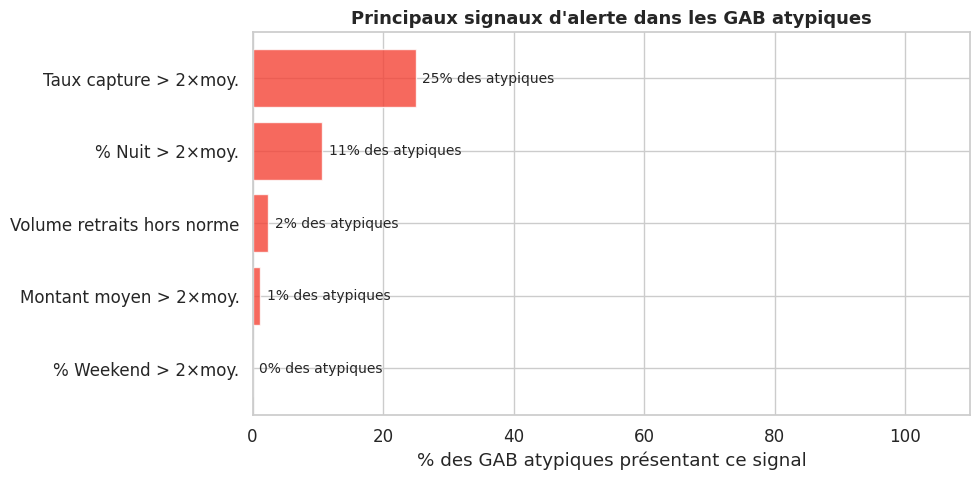

In [36]:
# ── 11.2 Graphique final : les signaux d'alerte par fréquence ─────────────────
anom_df = df[df['est_anomalie']==1]
norm_df = df[df['est_anomalie']==0]

signaux = {
    'Taux capture > 2×moy.':       (anom_df['taux_capture_pct']   > norm_df['taux_capture_pct'].mean()*2).mean()*100,
    'Montant moyen > 2×moy.':      (anom_df['ret_montant_moyen']  > norm_df['ret_montant_moyen'].mean()*2).mean()*100,
    '% Nuit > 2×moy.':             (anom_df['ret_pct_nuit']       > norm_df['ret_pct_nuit'].mean()*2).mean()*100,
    '% Weekend > 2×moy.':          (anom_df['ret_pct_weekend']    > norm_df['ret_pct_weekend'].mean()*2).mean()*100,
    'Volume retraits hors norme':   (anom_df['ret_nb'].abs()       > norm_df['ret_nb'].mean()*2).mean()*100,
}

signaux_series = pd.Series(signaux).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(signaux_series.index, signaux_series.values,
               color=COULEUR_ANOMALIE, alpha=0.8, edgecolor='white')

for bar, val in zip(bars, signaux_series.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}% des atypiques', va='center', fontsize=10)

ax.set_xlabel('% des GAB atypiques présentant ce signal')
ax.set_title('Principaux signaux d\'alerte dans les GAB atypiques', fontsize=13, fontweight='bold')
ax.set_xlim(0, 110)
plt.tight_layout()
plt.savefig('signaux_alerte.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
# ── 11.3 Export — liste priorisée des GAB à investiguer ─────────────────────
cp_col = 'code_postale_emplacement' if 'code_postale_emplacement' in df.columns else 'code_postal'

cols_export = ['num_automate', cp_col, 'contexte_geo', 'score_risque',
               'ret_nb_horscos', 'ret_montant_moyen', 'taux_capture_pct',
               'ret_pct_nuit', 'ret_pct_weekend', 'pct_reseaux_etrangers',
               'reseau_dominant', 'cluster_nom', 'type_gab_e_i']
if 'raison_principale' in df.columns:
    cols_export.insert(3, 'raison_principale')
cols_export = [c for c in cols_export if c in df.columns]

liste_inv = (df[df['est_anomalie']==1][cols_export]
             .sort_values('score_risque', ascending=False)
             .reset_index(drop=True))
liste_inv.index += 1

# Décommenter pour exporter :
# liste_inv.to_csv('gab_a_investiguer.csv', index=True)
# import dataiku
# dataiku.Dataset('gab_atypiques_a_investiguer').write_with_schema(liste_inv)

fmt_exp = {'score_risque':'{:.3f}','taux_capture_pct':'{:.2f}',
           'ret_montant_moyen':'{:.0f}','ret_pct_nuit':'{:.1f}',
           'pct_reseaux_etrangers':'{:.1f}'}
fmt_exp = {k:v for k,v in fmt_exp.items() if k in liste_inv.columns}

print(f'📋 {len(liste_inv)} GAB recommandés pour investigation (priorisés par score) :')
display(liste_inv.head(15).style
    .background_gradient(subset=['score_risque'], cmap='Reds')
    .format(fmt_exp))


📋 84 GAB recommandés pour investigation (priorisés par score) :


,num_automate,code_postale_emplacement,contexte_geo,raison_principale,score_risque,ret_nb_horscos,ret_montant_moyen,taux_capture_pct,ret_pct_nuit,ret_pct_weekend,pct_reseaux_etrangers,reseau_dominant,cluster_nom,type_gab_e_i
1,GAB_0138,97100,Guadeloupe,Concentration anormale sur réseaux étrangers (43.8% du total),1.000,480,144,0.93,9.8,19.680748,43.8,cb,🔴 C1 — Profil à risque élevé,Interne
2,GAB_0122,97300,Guyane,Concentration anormale sur réseaux étrangers (47.5% du total),0.991,300,152,0.28,14.0,22.736412,47.5,jcb,🔴 C1 — Profil à risque élevé,Externe
3,GAB_0122,97300,Guyane,Concentration anormale sur réseaux étrangers (47.3% du total),0.972,409,116,0.95,9.6,24.355894,47.3,jcb,🔴 C1 — Profil à risque élevé,Externe
4,GAB_0134,69001,Métropole,Taux de capture anormalement élevé (1.5% vs moy. réseau 0.7%),0.970,1192,167,1.55,12.2,25.722101,47.6,cb,🔴 C1 — Profil à risque élevé,Externe
5,GAB_0134,69001,Métropole,Concentration anormale sur réseaux étrangers (47.1% du total),0.922,1131,189,0.61,11.8,22.145738,47.1,jcb,🔴 C1 — Profil à risque élevé,Externe
6,GAB_0130,97150,Saint-Martin,Concentration anormale sur réseaux étrangers (42.8% du total),0.905,225,188,0.49,8.3,19.435639,42.8,cb,🔴 C1 — Profil à risque élevé,Externe
7,GAB_0138,97100,Guadeloupe,Activité nocturne excessive (17.3% vs moy. 10.8%),0.904,346,164,0.70,17.3,21.754216,49.6,jcb,🔴 C1 — Profil à risque élevé,Externe
8,GAB_0126,97300,Guyane,Concentration anormale sur réseaux étrangers (46.6% du total),0.901,411,181,0.34,8.4,29.678082,46.6,jcb,🔴 C1 — Profil à risque élevé,Externe
9,GAB_0130,97150,Saint-Martin,Concentration anormale sur réseaux étrangers (47.4% du total),0.884,302,174,0.61,11.7,18.863465,47.4,jcb,🔴 C1 — Profil à risque élevé,Interne
10,GAB_0126,97300,Guyane,Taux de capture anormalement élevé (1.3% vs moy. réseau 0.7%),0.883,366,170,1.31,14.1,21.928989,50.4,jcb,🔴 C1 — Profil à risque élevé,Interne


## 12. 📌 Conclusion & Recommandations

---

### Ce que le modèle apporte

| Ce que vous faisiez avant | Ce que le modèle permet maintenant |
|---|---|
| Surveillance manuelle par seuil | Détection automatique multi-dimensionnelle |
| Anomalies évidentes seulement | Détection de signaux faibles combinés |
| Analyse rétrospective | Alerte mensuelle systématique |
| Subjectif / expertise individuelle | Reproductible et documenté |

---

### Prochaines étapes recommandées

1. **Validation métier** : soumettre la liste des GAB détectés aux experts pour qualification (vrai/faux positif)
2. **Enrichissement** : intégrer des données de contexte (incidents déclarés, interventions techniques)
3. **Mise en production** : exécution mensuelle automatique dans Dataiku
4. **Amélioration continue** : avec les retours métier, passer progressivement à un modèle semi-supervisé

---

> *« Un modèle n'est pas là pour remplacer l'expertise métier, mais pour l'amplifier.  
> Il voit ce que l'œil ne peut pas voir sur 500 automates simultanément. »*

---